# CFRM 521/421 Machine Learning for Finance

**Project Title:** 
Volatility Prediction of Microsoft Using Machine Learning

**Group Members:**  
- Jenny Fu (email: jennyfu1@uw.edu, Algorithm: Support Vector Regression)  
- Emma Xu (email: zihanxu@uw.edu, Algorithm: Gradient Boosing)  
- Shawn Wen (email: shaobw@uw.edu, Algorithm: Recurrent Neural Network)  
- Zihan Zhu (email: zihanzhu@uw.edu, Algorithm: Random Forest)  

**Date:** 
2026/06/05

<span style="color:red">
**Please remove the bullet points in each section as you proceed and feel free to adjust the structure and contents as needed.
</span>

# 1. Introduction

## 1.1 Problem Statement
- What is the goal of your project?
- Why is this problem important in finance?
- What financial decision, prediction, or classification task are you studying?

## 1.2 Related Literature
- Briefly summarize relevant papers or prior work.
- Explain how your project relates to existing studies.
- Cite all sources properly.

## 1.3 Contribution
- What does your project add beyond existing work?
- Is your contribution empirical comparison, replication with extensions, new data, or a new application?


# 2. Data Description

## 2.1 Data Source
- Describe the original source of the data.
- Include links, API names, or repository names if relevant.

## 2.2 Data Structure
- What does each row represent?
- What is the sampling frequency?
- How many observations are there?
- What time period does the data cover?

## 2.3 Target Variable
- Define the response variable clearly.

## 2.4 Features
- List and briefly describe the predictors.
- Give a few examples.

## 2.5 Data Cleaning and Preprocessing
- Missing values
- Outlier handling
- Scaling or normalization
- Feature engineering
- Train/validation/test split


In [2]:
# Import Useful Libraries
from data_processing import feature_engineering
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducibility
np.random.seed(42)

Let's firstly load data from Yahoo Fiannce.

In [17]:
# Load Data from Yahoo Finance
tickers = [
    'MSFT',
    'SPY',
    'QQQ',
    'XLK',
    '^VIX',
    '^VXN',
    '^TNX',
    'SOXX',
    'TLT'
]

data = yf.download(
    tickers,
    start='2016-01-01',
    end='2026-01-01',
    auto_adjust=True
)

[*********************100%***********************]  9 of 9 completed


In [33]:
data.head()

,MSFT_Close,QQQ_Close,SOXX_Close,SPY_Close,TLT_Close,XLK_Close,^TNX_Close,^VIX_Close,^VXN_Close,MSFT_High,...,^VXN_Open,MSFT_Volume,QQQ_Volume,SOXX_Volume,SPY_Volume,TLT_Volume,XLK_Volume,^TNX_Volume,^VIX_Volume,^VXN_Volume
Date,,,,,,,,,,,,,,,,,,,,,
2016-01-04,47.770721,101.717308,26.696749,169.908142,90.984543,18.860455,2.245,20.700001,22.420000,47.770721,...,19.629999,53778000,50807600,1023000,222353500,10591900,43277200,0.0,0,0
2016-01-05,47.988651,101.540779,26.444214,170.195526,90.617500,18.811371,2.248,19.340000,21.559999,48.285039,...,22.440001,34079700,38795200,1329000,110845800,6242600,32134400,0.0,0,0
2016-01-06,47.116932,100.565422,25.530272,168.048676,91.838600,18.579353,2.177,20.590000,22.480000,47.422039,...,21.559999,39518900,41891100,1541100,152112600,8916900,27716800,0.0,0,0
2016-01-07,45.478088,97.416344,24.814751,164.016876,92.003372,18.030535,2.153,24.990000,26.770000,46.628773,...,22.500000,56564900,61386300,2026800,213436100,10202200,33681400,0.0,0,0
2016-01-08,45.617546,96.617462,24.456997,162.216553,92.415466,17.887754,2.130,27.010000,28.330000,46.445685,...,26.879999,48754000,69344000,1465200,209817200,9577200,38466200,0.0,0,0


In [18]:
model_data, feature_cols, target_cols = feature_engineering(data)


/Users/vinsber/Desktop/untitled folder 3/data_processing.py:80: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['TNX_change'] = df['TNX_Close'].pct_change()


In [19]:
print("Model data shape:", model_data.shape)
print("Total number of features:", len(feature_cols))

Model data shape: (2365, 65)
Total number of features: 39


In [20]:
# Check highly correlated features after removing redundant features
corr_matrix = model_data[feature_cols].corr().abs()

high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > 0.90:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_matrix.iloc[i, j]
            ))

high_corr_df = pd.DataFrame(
    high_corr_pairs,
    columns=['Feature 1', 'Feature 2', 'Correlation']
).sort_values(by='Correlation', ascending=False)

high_corr_df

,Feature 1,Feature 2,Correlation
8,MSFT_rolling_vol_63,MSFT_vol_63_lag1,0.997747
2,MSFT_rolling_vol_21,MSFT_vol_21_lag1,0.989264
7,VIX_rolling_mean_21,VXN_rolling_mean_21,0.969046
5,VIX_level,VXN_level,0.964111
3,SPY_log_return,XLK_log_return,0.930893
6,VIX_log_change,VXN_log_change,0.912825
1,MSFT_rolling_vol_21,SPY_rolling_vol_21,0.909308
4,SPY_rolling_vol_21,MSFT_vol_21_lag1,0.903306
0,MSFT_rolling_vol_5,MSFT_vol_5_lag1,0.902206


After feature engineering, we found that some variables are still highly correlated. For example, MSFT rolling volatility and its lagged volatility are almost identical in some windows. These strong correlations may make the regression results less stable, so we plan to use LASSO regularization to help select the most useful features and reduce redundancy.

Perform train/validation/test split in context of time-series and data standardization

In [22]:
# Time-series train / validation / test split
model_data = model_data.sort_index()

n = len(model_data)
train_end = int(n * 0.70)
valid_end = int(n * 0.85)


train_data = model_data.iloc[:train_end]
valid_data = model_data.iloc[train_end:valid_end]
test_data = model_data.iloc[valid_end:]

print("Total observations:", n)
print("Train shape:", train_data.shape)
print("Validation shape:", valid_data.shape)
print("Test shape:", test_data.shape)


# Define X variables
X_train = train_data[feature_cols]
X_valid = valid_data[feature_cols]
X_test = test_data[feature_cols]


# Define y variables
# Daily target
y_train_1d = train_data['target_volatility_1d']
y_valid_1d = valid_data['target_volatility_1d']
y_test_1d = test_data['target_volatility_1d']

# Weekly target
y_train_5d = train_data['target_volatility_5d']
y_valid_5d = valid_data['target_volatility_5d']
y_test_5d = test_data['target_volatility_5d']

# Monthly target
y_train_21d = train_data['target_volatility_21d']
y_valid_21d = valid_data['target_volatility_21d']
y_test_21d = test_data['target_volatility_21d']

Total observations: 2365
Train shape: (1655, 65)
Validation shape: (355, 65)
Test shape: (355, 65)


In [23]:
# Standardization
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    index=X_train.index,
    columns=feature_cols
)

X_valid_scaled = pd.DataFrame(
    X_valid_scaled,
    index=X_valid.index,
    columns=feature_cols
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    index=X_test.index,
    columns=feature_cols
)

After all data processing, let's perform feature selection with the use of LASSO Regularization method.

In [24]:
from sklearn.linear_model import LassoCV

lasso = LassoCV(
    cv=5,
    random_state=42,
    max_iter=100000
)

lasso.fit(
    X_train_scaled,
    y_train_21d
)

lasso_coef = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": lasso.coef_
})

lasso_coef["AbsCoefficient"] = (
    lasso_coef["Coefficient"].abs()
)

lasso_coef = (
    lasso_coef
    .sort_values(
        by="AbsCoefficient",
        ascending=False
    )
)

print("Best alpha:", lasso.alpha_)
print("Selected features:",
      (lasso_coef["Coefficient"] != 0).sum())

Best alpha: 0.0007079227328138667
Selected features: 5


After applying LASSO regularization, only five features were selected with non-zero coefficients. This suggests that a relatively small subset of variables contains most of the predictive information for future MSFT volatility. Among the selected features, VXN_level and VIX_relative represent market volatility conditions, TNX_level reflects interest rate expectations, MSFT_log_volume captures trading activity, and vol_ratio_21_63 measures changes in volatility across different time horizons. These variables are therefore retained for subsequent model construction.

In [25]:
top5_features = (
    lasso_coef
    .head(5)["Feature"]
    .tolist()
)

print(top5_features)

['VXN_level', 'vol_ratio_21_63', 'VIX_relative', 'MSFT_log_volume', 'TNX_level']


In [26]:
X_train_scaled = X_train_scaled[top5_features]
X_valid_scaled = X_valid_scaled[top5_features]
X_test_scaled  = X_test_scaled[top5_features]

In [31]:
model_data = df[top5_features + target_cols]

# 3. Exploratory Data Analysis

- Summarize the data.
- Visualize key variables.
- Examine the target variable.
- Discuss stylized facts or empirical patterns relevant to the financial problem.


In [32]:
# Basic summary statistics
print("Dataset shape:", model_data.shape)
print("Start date:", model_data.index.min())
print("End date:", model_data.index.max())

model_data.describe()

Dataset shape: (2365, 8)
Start date: 2016-07-05 00:00:00
End date: 2025-12-01 00:00:00


,VXN_level,vol_ratio_21_63,VIX_relative,MSFT_log_volume,TNX_level,target_volatility_1d,target_volatility_5d,target_volatility_21d
count,2365.000000,2365.000000,2365.000000,2365.000000,2365.000000,2365.000000,2365.000000,2365.000000
mean,22.515899,0.977771,1.005075,17.041344,2.725900,0.011591,0.014259,0.015138
std,7.556044,0.247558,0.175198,0.370675,1.186787,0.012301,0.010022,0.007814
min,10.310000,0.241652,0.656359,15.784649,0.499000,0.000000,0.000685,0.003449
25%,17.030001,0.823890,0.905451,16.786884,1.716000,0.003450,0.007868,0.010160
50%,20.549999,0.963277,0.973181,16.998933,2.659000,0.008041,0.011931,0.013476
75%,26.809999,1.143914,1.064179,17.254084,3.886000,0.015702,0.017981,0.018315
max,80.080002,1.669596,2.878466,18.527219,4.988000,0.159453,0.122156,0.071225


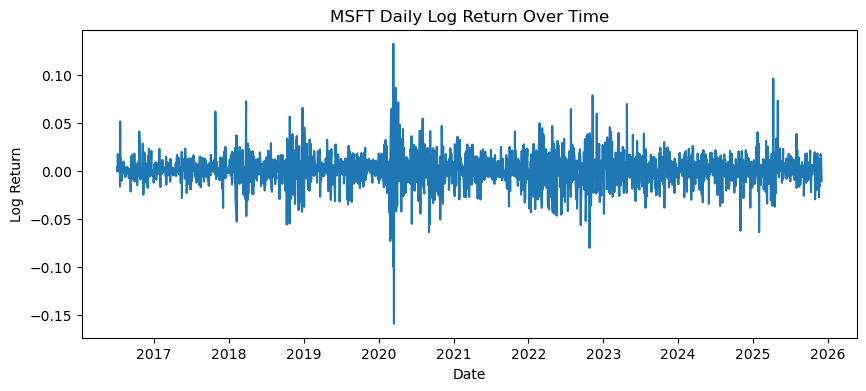

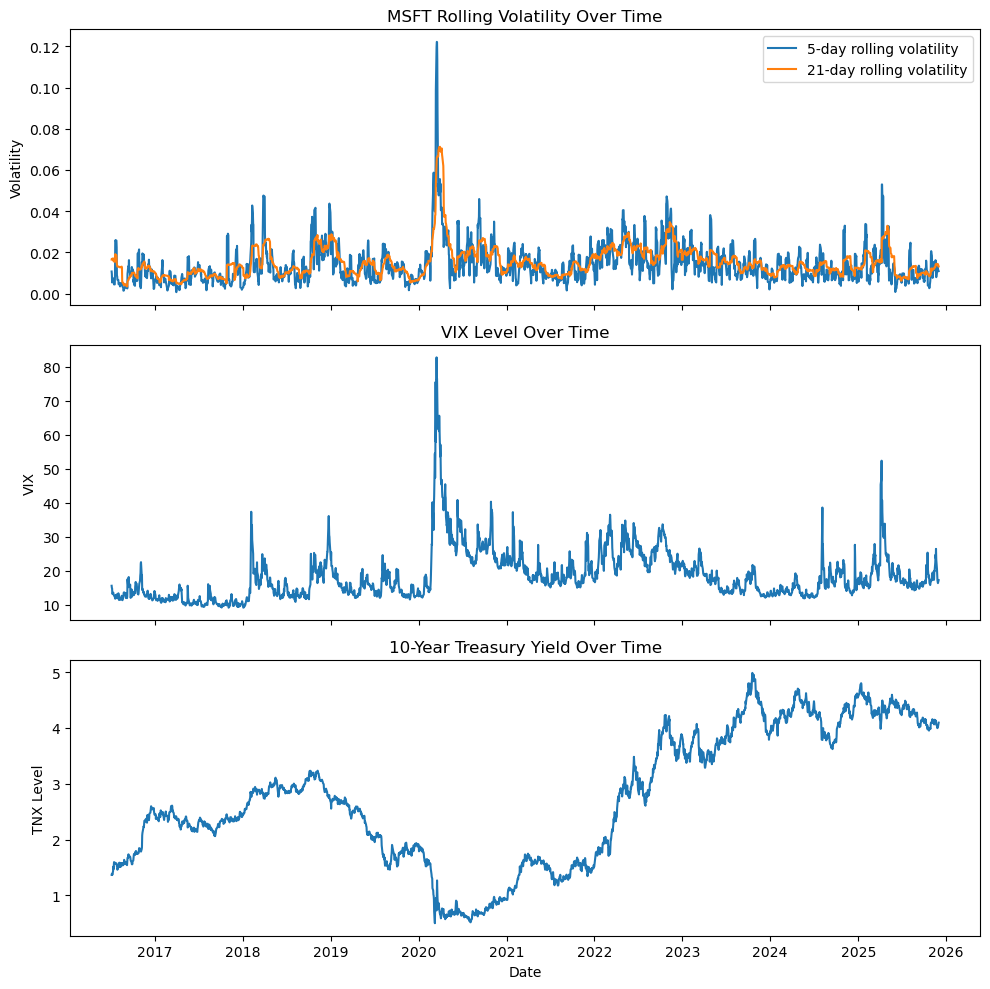

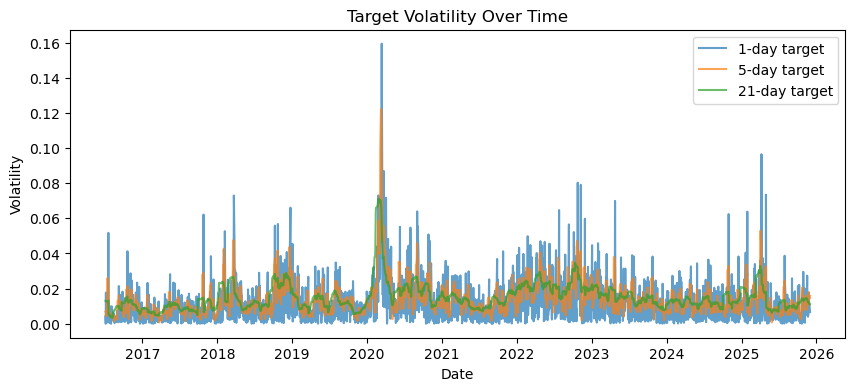

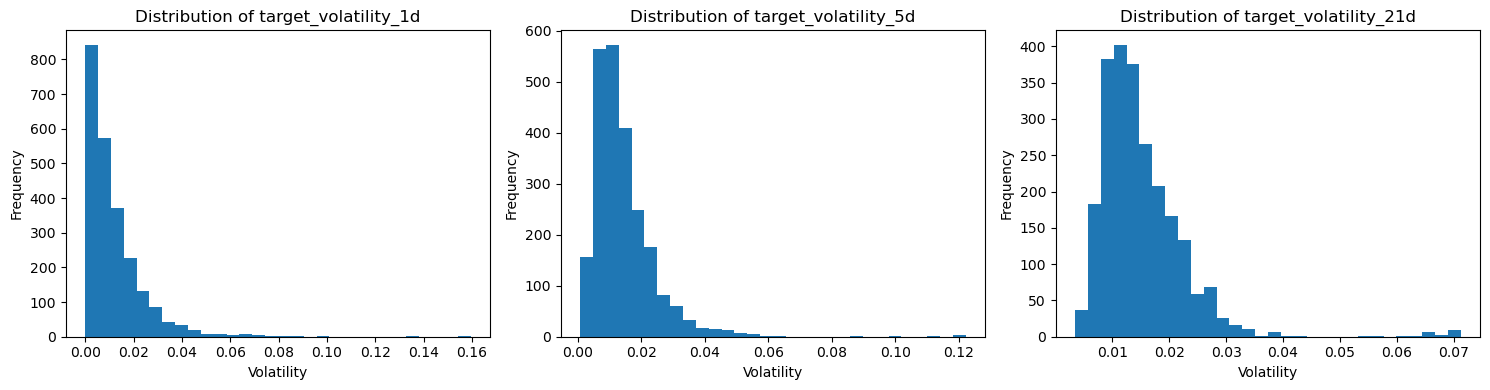

In [19]:
# Example visualization
# MSFT return over time
plt.figure(figsize=(10, 4))
plt.plot(model_data.index, model_data['MSFT_log_return'])
plt.title('MSFT Daily Log Return Over Time')
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.show()

# Market and volatility features over time
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
axes[0].plot(model_data.index, model_data['MSFT_rolling_vol_5'], label='5-day rolling volatility')
axes[0].plot(model_data.index, model_data['MSFT_rolling_vol_21'], label='21-day rolling volatility')
axes[0].set_title('MSFT Rolling Volatility Over Time')
axes[0].set_ylabel('Volatility')
axes[0].legend()

axes[1].plot(model_data.index, model_data['VIX_level'])
axes[1].set_title('VIX Level Over Time')
axes[1].set_ylabel('VIX')

axes[2].plot(model_data.index, model_data['TNX_level'])
axes[2].set_title('10-Year Treasury Yield Over Time')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('TNX Level')
plt.tight_layout()
plt.show()

# Target volatility over time
plt.figure(figsize=(10, 4))
plt.plot(model_data.index, model_data['target_volatility_1d'], label='1-day target', alpha=0.7)
plt.plot(model_data.index, model_data['target_volatility_5d'], label='5-day target', alpha=0.7)
plt.plot(model_data.index, model_data['target_volatility_21d'], label='21-day target', alpha=0.7)
plt.title('Target Volatility Over Time')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.legend()
plt.show()

# Distribution of target variables
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, target_cols):
    ax.hist(model_data[col], bins=30)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel('Volatility')
    ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

# 4. Methodology

Clearly separate the problem description from the learning algorithms.

Include a separate subsection for hyperparameter tuning:
- Explain how tuning is performed.
- Make the comparison fair across models.
- State the validation procedure clearly.

## 4.1 Overview of Models
- You must try at least as many algorithms as group members.
- Each group member should implement at least one algorithm.
- Use models within the scope of the course.
- If using a more advanced model, provide sufficient background and compare it against standard baselines first.


## 4.2 Model 1: Support Vector Regression (SVR)

**Implemented by: Jenny Fu**

- Motivation

Support Vector Regression (SVR) is used because future MSFT volatility may not have a simple linear relationship with the input features. Market variables such as VIX, VXN, lagged returns, rolling volatility, sector ETFs, and interest rates may affect volatility in nonlinear ways. Compared with ordinary linear regression, SVR with a kernel function can model more flexible relationships.

SVR is also suitable for noisy financial data because it uses an epsilon-insensitive margin. Small prediction errors within the margin are not penalized, while larger errors receive penalties.

- Model description

Support Vector Regression is the regression version of Support Vector Machine. Instead of classifying observations, SVR predicts a continuous target variable:

\[
f(x) = w^T x + b
\]

A key idea is the epsilon-insensitive tube. Errors within \(\epsilon\) receive no penalty, while errors outside the tube are penalized. In this project, we use SVR with an RBF kernel to capture nonlinear relationships. The main hyperparameters are \(C\), \(\epsilon\), and \(\gamma\), which control the penalty strength, margin width, and kernel flexibility.

- Why this method is appropriate/Key assumptions

SVR is appropriate because volatility prediction may depend on nonlinear combinations of historical returns, market volatility, sector movements, and interest rates. Since SVR is sensitive to feature scale, all input features are standardized. To avoid data leakage, the scaler is fitted only on the training set and then applied to the validation and test sets. The data are also split chronologically so that the model is trained on earlier observations and evaluated on later observations.

In [20]:
# SVR Training + Validation Hyperparameter Tuning
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

param_grid = [
    {'C': 0.1, 'epsilon': 0.0005, 'gamma': 'scale'},
    {'C': 1,   'epsilon': 0.0005, 'gamma': 'scale'},
    {'C': 10,  'epsilon': 0.0005, 'gamma': 'scale'},

    {'C': 0.1, 'epsilon': 0.001, 'gamma': 'scale'},
    {'C': 1,   'epsilon': 0.001, 'gamma': 'scale'},
    {'C': 10,  'epsilon': 0.001, 'gamma': 'scale'},

    {'C': 0.1, 'epsilon': 0.005, 'gamma': 'scale'},
    {'C': 1,   'epsilon': 0.005, 'gamma': 'scale'},
    {'C': 10,  'epsilon': 0.005, 'gamma': 'scale'},

    {'C': 0.1, 'epsilon': 0.01, 'gamma': 'scale'},
    {'C': 1,   'epsilon': 0.01, 'gamma': 'scale'},
    {'C': 10,  'epsilon': 0.01, 'gamma': 'scale'},
]


def tune_svr_validation(
    target_name,
    y_train,
    y_valid,
    X_train_scaled,
    X_valid_scaled,
    param_grid
):
    validation_results = []

    for params in param_grid:
        svr = SVR(
            kernel='rbf',
            C=params['C'],
            epsilon=params['epsilon'],
            gamma=params['gamma']
        )

        # Train on training set
        svr.fit(X_train_scaled, y_train)

        # Predict on validation set
        y_valid_pred = svr.predict(X_valid_scaled)

        # Validation metrics
        valid_mae = mean_absolute_error(y_valid, y_valid_pred)
        valid_rmse = np.sqrt(mean_squared_error(y_valid, y_valid_pred))
        valid_r2 = r2_score(y_valid, y_valid_pred)
        valid_normalized_rmse = valid_rmse / np.std(y_valid)

        validation_results.append({
            "Target": target_name,
            "C": params["C"],
            "epsilon": params["epsilon"],
            "gamma": params["gamma"],
            "Validation MAE": valid_mae,
            "Validation RMSE": valid_rmse,
            "Validation Normalized RMSE": valid_normalized_rmse,
            "Validation R2": valid_r2,
            "Model": svr
        })

    validation_df = pd.DataFrame(validation_results)

    # Mark the best hyperparameter combination for this target
    best_idx = validation_df["Validation RMSE"].idxmin()
    validation_df["Best"] = ""
    validation_df.loc[best_idx, "Best"] = "Best"

    best_model = validation_df.loc[best_idx, "Model"]

    return validation_df, best_model

In [23]:
# Run SVR validation tuning for three targets
targets = {
    "1-day volatility": (y_train_1d, y_valid_1d),
    "5-day volatility": (y_train_5d, y_valid_5d),
    "21-day volatility": (y_train_21d, y_valid_21d)
}

all_validation_tables = []
best_svr_models = {}

for target_name, (y_train, y_valid) in targets.items():

    validation_df, best_model = tune_svr_validation(
        target_name=target_name,
        y_train=y_train,
        y_valid=y_valid,
        X_train_scaled=X_train_scaled,
        X_valid_scaled=X_valid_scaled,
        param_grid=param_grid
    )

    all_validation_tables.append(validation_df)
    best_svr_models[target_name] = best_model

In [24]:
# Best SVR Validation Table
svr_validation_table = pd.concat(all_validation_tables, ignore_index=True)

best_svr_validation_table = (
    svr_validation_table[svr_validation_table["Best"] == "Best"]
    .drop(columns=["Model"])
    .copy()
    .reset_index(drop=True)
)

numeric_cols = [
    "Validation MAE",
    "Validation RMSE",
    "Validation Normalized RMSE",
    "Validation R2"
]

best_svr_validation_table[numeric_cols] = (
    best_svr_validation_table[numeric_cols].round(4)
)

best_svr_validation_table

,Target,C,epsilon,gamma,Validation MAE,Validation RMSE,Validation Normalized RMSE,Validation R2,Best
0,1-day volatility,0.1,0.010,scale,0.0080,0.0099,1.0818,-0.1704,Best
1,5-day volatility,0.1,0.005,scale,0.0129,0.0151,2.6214,-5.8718,Best
2,21-day volatility,10.0,0.010,scale,0.0071,0.0091,3.1261,-8.7727,Best


## 4.3 Model 2: Gradient Boost

**Implemented by: Emma Xu** 

- Motivation

Gradient Boosting is used because stock volatility is likely driven by nonlinear relationships among market variables. For example, the effect of VIX on MSFT volatility may become stronger during high-volatility periods, and recent MSFT volatility may interact with market-wide volatility measures such as SPY and XLK rolling volatility. A simple linear model may not fully capture these nonlinear patterns.

- Model description

Gradient Boosting is an ensemble learning method that builds many decision trees sequentially. Each new tree is trained to correct the prediction errors made by the previous trees. Instead of fitting one large tree, the model combines many small trees to gradually improve prediction accuracy.

- Why this method is appropriate

This method is appropriate for volatility prediction because financial volatility often has nonlinear behavior, volatility clustering, and interactions between stock-specific and market-wide variables. Gradient Boosting can capture these complex patterns without requiring us to manually specify nonlinear terms.


In [29]:
# Gradient Boosting Training + Validation Hyperparameter Tuning
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

gb_param_grid = [
    {'n_estimators': 50,  'learning_rate': 0.01, 'max_depth': 2},
    {'n_estimators': 50,  'learning_rate': 0.03, 'max_depth': 2},
    {'n_estimators': 50,  'learning_rate': 0.05, 'max_depth': 2},

    {'n_estimators': 100, 'learning_rate': 0.01, 'max_depth': 2},
    {'n_estimators': 100, 'learning_rate': 0.03, 'max_depth': 2},
    {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 2},

    {'n_estimators': 200, 'learning_rate': 0.01, 'max_depth': 2},
    {'n_estimators': 200, 'learning_rate': 0.03, 'max_depth': 2},
    {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 2},

    {'n_estimators': 300, 'learning_rate': 0.01, 'max_depth': 2},
    {'n_estimators': 300, 'learning_rate': 0.03, 'max_depth': 2},
    {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 2},
]


def tune_gb_validation(
    target_name,
    y_train,
    y_valid,
    X_train_scaled,
    X_valid_scaled,
    param_grid
):
    """
    Train Gradient Boosting models with different hyperparameter combinations.
    Evaluate each model on the validation set.
    Select the best model based on validation RMSE.
    """

    validation_results = []

    for params in param_grid:

        gb = GradientBoostingRegressor(
            n_estimators=params["n_estimators"],
            learning_rate=params["learning_rate"],
            max_depth=params["max_depth"],
            random_state=42
        )

        # Train on training set
        gb.fit(X_train_scaled, y_train)

        # Predict on validation set
        y_valid_pred = gb.predict(X_valid_scaled)

        # Validation metrics
        valid_mae = mean_absolute_error(y_valid, y_valid_pred)
        valid_rmse = np.sqrt(mean_squared_error(y_valid, y_valid_pred))
        valid_r2 = r2_score(y_valid, y_valid_pred)
        valid_normalized_rmse = valid_rmse / np.std(y_valid)

        validation_results.append({
            "Target": target_name,
            "n_estimators": params["n_estimators"],
            "learning_rate": params["learning_rate"],
            "max_depth": params["max_depth"],
            "Validation MAE": valid_mae,
            "Validation RMSE": valid_rmse,
            "Validation Normalized RMSE": valid_normalized_rmse,
            "Validation R2": valid_r2,
            "Model": gb
        })

    validation_df = pd.DataFrame(validation_results)

    # Mark the best hyperparameter combination for this target
    best_idx = validation_df["Validation RMSE"].idxmin()
    validation_df["Best"] = ""
    validation_df.loc[best_idx, "Best"] = "Best"

    best_model = validation_df.loc[best_idx, "Model"]

    return validation_df, best_model

In [30]:
# Run Gradient Boosting validation tuning for three targets
gb_targets = {
    "1-day volatility": (y_train_1d, y_valid_1d),
    "5-day volatility": (y_train_5d, y_valid_5d),
    "21-day volatility": (y_train_21d, y_valid_21d)
}

all_gb_validation_tables = []
best_gb_models = {}

for target_name, (y_train, y_valid) in gb_targets.items():

    validation_df, best_model = tune_gb_validation(
        target_name=target_name,
        y_train=y_train,
        y_valid=y_valid,
        X_train_scaled=X_train_scaled,
        X_valid_scaled=X_valid_scaled,
        param_grid=gb_param_grid
    )

    all_gb_validation_tables.append(validation_df)
    best_gb_models[target_name] = best_model

In [27]:
# Best Gradient Boosting Validation Table
gb_validation_table = pd.concat(all_gb_validation_tables, ignore_index=True)

best_gb_validation_table = (
    gb_validation_table[gb_validation_table["Best"] == "Best"]
    .drop(columns=["Model"])
    .copy()
    .reset_index(drop=True)
)

numeric_cols = [
    "Validation MAE",
    "Validation RMSE",
    "Validation Normalized RMSE",
    "Validation R2"
]

best_gb_validation_table[numeric_cols] = (
    best_gb_validation_table[numeric_cols].round(4)
)

best_gb_validation_table

,Target,n_estimators,learning_rate,max_depth,Validation MAE,Validation RMSE,Validation Normalized RMSE,Validation R2,Best
0,1-day volatility,100,0.01,2,0.0069,0.0089,0.9753,0.0487,Best
1,5-day volatility,50,0.01,2,0.0045,0.0056,0.9766,0.0462,Best
2,21-day volatility,100,0.01,2,0.0023,0.0028,0.9500,0.0975,Best


## 4.4 Model 3: Recurrent Neural Network (SimpleRNN)

**Implemented by: Shawn Wen** 

- Motivation

The models discussed so far — SVR, Gradient Boosting, and Lasso — treat each observation independently. They receive a fixed feature vector at time $t$ and predict volatility at $t+h$, with no explicit memory of the sequence leading up to $t$. Volatility, however, is inherently a time-series phenomenon: large moves tend to cluster together (volatility clustering), and market regimes (high-vol vs. low-vol) can persist for weeks. A Recurrent Neural Network explicitly models this temporal structure by maintaining a hidden state that accumulates information across time steps, making it a natural fit for this task.
  
- Model description

At each time step $t$, a SimpleRNN layer updates its hidden state as:

$$h_t = \tanh(W_x x_t + W_h h_{t-1} + b)$$

where $x_t$ is the input at time $t$, $h_{t-1}$ is the previous hidden state, and $W_x$, $W_h$, $b$ are learned parameters. We stack two recurrent layers (with the first returning the full sequence to the second), followed by a single Dense output neuron. The model is trained with the Nadam optimizer and MSE loss.

We use a **sliding window** approach: at each time step, the model receives a sequence of the past `window_size` days of features and predicts the forward volatility.

- Why this method is appropriate

RNN is appropriate because it directly learns temporal dependencies from the raw sequence rather than relying on manually engineered lag features. Volatility clustering — the tendency for high-volatility periods to persist — is exactly the kind of sequential pattern RNNs are designed to capture. We use early stopping based on validation loss to prevent overfitting on the ~2,500 daily observations available.

In [31]:
# RNN Training + Validation Hyperparameter Tuning
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")


# Sequence helper
def make_sequences(X, y, window_size):
    Xs = []
    ys = []

    for i in range(len(X) - window_size + 1):
        Xs.append(X[i:i + window_size])
        ys.append(y[i + window_size - 1])

    return (
        np.array(Xs, dtype=np.float32),
        np.array(ys, dtype=np.float32)
    )


# RNN model
class SimpleRNNRegressor(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()

        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=2,
            batch_first=True,
            nonlinearity="tanh"
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])
        return out.squeeze(-1)


# Train helper
def train_rnn(
    model,
    X_train_seq,
    y_train_seq,
    X_valid_seq,
    y_valid_seq,
    epochs=100,
    batch_size=32,
    patience=15
):
    optimizer = torch.optim.Adam(model.parameters())
    criterion = nn.MSELoss()

    train_ds = TensorDataset(
        torch.tensor(X_train_seq),
        torch.tensor(y_train_seq)
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=False
    )

    X_valid_t = torch.tensor(X_valid_seq).to(device)
    y_valid_t = torch.tensor(y_valid_seq).to(device)

    model.to(device)

    best_val_loss = float("inf")
    best_state = None
    patience_count = 0

    train_losses = []
    valid_losses = []

    for epoch in range(epochs):
        model.train()

        total_loss = 0

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()

            pred = model(xb)
            loss = criterion(pred, yb)

            loss.backward()
            optimizer.step()

            total_loss += loss.item() * len(xb)

        train_loss = total_loss / len(train_ds)
        train_losses.append(train_loss)

        model.eval()

        with torch.no_grad():
            valid_loss = criterion(
                model(X_valid_t),
                y_valid_t
            ).item()

        valid_losses.append(valid_loss)

        if valid_loss < best_val_loss:
            best_val_loss = valid_loss
            best_state = {
                k: v.clone()
                for k, v in model.state_dict().items()
            }
            patience_count = 0
        else:
            patience_count += 1

            if patience_count >= patience:
                break

    model.load_state_dict(best_state)

    return model, train_losses, valid_losses


# RNN validation tuning function
def tune_rnn_validation(
    target_name,
    y_train,
    y_valid,
    X_train_scaled,
    X_valid_scaled,
    input_size,
    param_grid
):
    """
    Train RNN models with different window sizes and hidden units.
    Evaluate each model on the validation set.
    Select the best model based on validation RMSE.
    """

    validation_results = []

    y_train_arr = y_train.values.astype(np.float32)
    y_valid_arr = y_valid.values.astype(np.float32)

    # Combine train and validation so validation sequences can use previous time steps
    X_train_valid = np.concatenate([X_train_scaled, X_valid_scaled])
    y_train_valid = np.concatenate([y_train_arr, y_valid_arr])

    for params in param_grid:

        window_size = params["window_size"]
        units = params["units"]

        X_seq, y_seq = make_sequences(
            X_train_valid,
            y_train_valid,
            window_size
        )

        n_train_seq = len(y_train_arr) - window_size + 1

        X_train_seq = X_seq[:n_train_seq]
        y_train_seq = y_seq[:n_train_seq]

        X_valid_seq = X_seq[n_train_seq:]
        y_valid_seq = y_seq[n_train_seq:]

        torch.manual_seed(42)

        model = SimpleRNNRegressor(
            input_size=input_size,
            hidden_size=units
        )

        model, train_losses, valid_losses = train_rnn(
            model,
            X_train_seq,
            y_train_seq,
            X_valid_seq,
            y_valid_seq
        )

        model.eval()

        with torch.no_grad():
            y_valid_pred = model(
                torch.tensor(X_valid_seq).to(device)
            ).cpu().numpy()

        valid_mae = mean_absolute_error(y_valid_seq, y_valid_pred)
        valid_rmse = np.sqrt(mean_squared_error(y_valid_seq, y_valid_pred))
        valid_r2 = r2_score(y_valid_seq, y_valid_pred)
        valid_normalized_rmse = valid_rmse / np.std(y_valid_seq)

        validation_results.append({
            "Target": target_name,
            "window_size": window_size,
            "units": units,
            "Validation MAE": valid_mae,
            "Validation RMSE": valid_rmse,
            "Validation Normalized RMSE": valid_normalized_rmse,
            "Validation R2": valid_r2,
            "Model": model,
            "Train Losses": train_losses,
            "Validation Losses": valid_losses
        })

    validation_df = pd.DataFrame(validation_results)

    best_idx = validation_df["Validation RMSE"].idxmin()
    validation_df["Best"] = ""
    validation_df.loc[best_idx, "Best"] = "Best"

    best_model = validation_df.loc[best_idx, "Model"]

    return validation_df, best_model


# RNN hyperparameter grid
rnn_param_grid = [
    {"window_size": 10, "units": 8},
    {"window_size": 10, "units": 16},
    {"window_size": 21, "units": 8},
    {"window_size": 21, "units": 16}
]

input_size = X_train_scaled.shape[1]

In [32]:
# Run RNN validation tuning for three targets
rnn_targets = {
    "1-day volatility": (y_train_1d, y_valid_1d),
    "5-day volatility": (y_train_5d, y_valid_5d),
    "21-day volatility": (y_train_21d, y_valid_21d)
}

all_rnn_validation_tables = []
best_rnn_models = {}

for target_name, (y_train, y_valid) in rnn_targets.items():

    validation_df, best_model = tune_rnn_validation(
        target_name=target_name,
        y_train=y_train,
        y_valid=y_valid,
        X_train_scaled=X_train_scaled,
        X_valid_scaled=X_valid_scaled,
        input_size=input_size,
        param_grid=rnn_param_grid
    )

    all_rnn_validation_tables.append(validation_df)
    best_rnn_models[target_name] = best_model

In [33]:
# Best RNN Validation Table
rnn_validation_table = pd.concat(all_rnn_validation_tables, ignore_index=True)

best_rnn_validation_table = (
    rnn_validation_table[rnn_validation_table["Best"] == "Best"]
    .drop(columns=["Model", "Train Losses", "Validation Losses"])
    .copy()
    .reset_index(drop=True)
)

numeric_cols = [
    "Validation MAE",
    "Validation RMSE",
    "Validation Normalized RMSE",
    "Validation R2"
]

best_rnn_validation_table[numeric_cols] = (
    best_rnn_validation_table[numeric_cols].round(4)
)

best_rnn_validation_table

,Target,window_size,units,Validation MAE,Validation RMSE,Validation Normalized RMSE,Validation R2,Best
0,1-day volatility,10,8,0.0076,0.0097,1.0591,-0.1218,Best
1,5-day volatility,10,16,0.0065,0.0082,1.4234,-1.0261,Best
2,21-day volatility,21,8,0.0064,0.0081,2.7698,-6.6718,Best


## 4.5 Model 4: Random Forest

**Implemented by: Zihan Zhu** 

- Motivation

Random Forest is chosen because future stock volatility may depend on complex interactions among market variables. Features such as VIX, SPY returns, QQQ returns, trading volume, lagged MSFT returns, and rolling volatility may influence future volatility in a nonlinear way. A simple linear model may not fully capture these relationships.

Random Forest is also robust to noisy financial data. By averaging predictions from many decision trees, it can reduce overfitting and improve prediction stability compared with a single decision tree.

- Model description

Random Forest is an ensemble learning method based on bagging. The model builds many decision trees using bootstrap samples of the training data. At each split, only a random subset of features is considered, which increases diversity among trees.

For a regression problem, the final prediction is the average prediction across all trees in the forest. In this project, we tune the main hyperparameters including the number of trees (n_estimators), maximum tree depth (max_depth), and minimum number of samples required in a leaf node (min_samples_leaf). The best parameter combination is selected using validation RMSE.


- Why this method is appropriate

Random Forest is appropriate because stock volatility often exhibits nonlinear behavior and interactions among market indicators. It can capture these patterns without requiring us to manually specify nonlinear terms or interaction effects.

The main assumption is that historical market information contains useful signals for future volatility prediction. We also split the data chronologically into training, validation, and test sets to avoid look-ahead bias. Since Random Forest is tree-based, feature scaling is not required, making it relatively robust to differences in feature magnitude.

In [34]:
# Random Forest Training + Validation Hyperparameter Tuning
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

rf_param_grid = []

# Round 1: Initial Search
for n_estimators in [100, 200]:
    for max_depth in [3, 5, 8]:
        for min_samples_leaf in [3, 5, 10]:
            rf_param_grid.append({
                "Search Round": "Initial Search",
                "n_estimators": n_estimators,
                "max_depth": max_depth,
                "min_samples_leaf": min_samples_leaf
            })

# Round 2: Refined Search
for max_depth in [2, 3, 4, 5, 6]:
    for min_samples_leaf in [8, 10, 12]:
        rf_param_grid.append({
            "Search Round": "Refined Search",
            "n_estimators": 200,
            "max_depth": max_depth,
            "min_samples_leaf": min_samples_leaf
        })


def tune_rf_validation(
    target_name,
    y_train,
    y_valid,
    X_train_scaled,
    X_valid_scaled,
    param_grid
):
    """
    Train Random Forest models with different hyperparameter combinations.
    Evaluate each model on the validation set.
    Select the best model based on validation RMSE.
    """

    validation_results = []

    for params in param_grid:

        rf = RandomForestRegressor(
            n_estimators=params["n_estimators"],
            max_depth=params["max_depth"],
            min_samples_leaf=params["min_samples_leaf"],
            random_state=42,
            n_jobs=-1
        )

        # Train on training set
        rf.fit(X_train_scaled, y_train)

        # Predict on validation set
        y_valid_pred = rf.predict(X_valid_scaled)

        # Validation metrics
        valid_mae = mean_absolute_error(y_valid, y_valid_pred)
        valid_rmse = np.sqrt(mean_squared_error(y_valid, y_valid_pred))
        valid_r2 = r2_score(y_valid, y_valid_pred)
        valid_normalized_rmse = valid_rmse / np.std(y_valid)

        validation_results.append({
            "Target": target_name,
            "Search Round": params["Search Round"],
            "n_estimators": params["n_estimators"],
            "max_depth": params["max_depth"],
            "min_samples_leaf": params["min_samples_leaf"],
            "Validation MAE": valid_mae,
            "Validation RMSE": valid_rmse,
            "Validation Normalized RMSE": valid_normalized_rmse,
            "Validation R2": valid_r2,
            "Model": rf
        })

    validation_df = pd.DataFrame(validation_results)

    # Mark the best hyperparameter combination for this target
    best_idx = validation_df["Validation RMSE"].idxmin()
    validation_df["Best"] = ""
    validation_df.loc[best_idx, "Best"] = "Best"

    best_model = validation_df.loc[best_idx, "Model"]

    return validation_df, best_model

In [35]:
# Run Random Forest validation tuning for three targets
rf_targets = {
    "1-day volatility": (y_train_1d, y_valid_1d),
    "5-day volatility": (y_train_5d, y_valid_5d),
    "21-day volatility": (y_train_21d, y_valid_21d)
}

all_rf_validation_tables = []
best_rf_models = {}

for target_name, (y_train, y_valid) in rf_targets.items():

    validation_df, best_model = tune_rf_validation(
        target_name=target_name,
        y_train=y_train,
        y_valid=y_valid,
        X_train_scaled=X_train_scaled,
        X_valid_scaled=X_valid_scaled,
        param_grid=rf_param_grid
    )

    all_rf_validation_tables.append(validation_df)
    best_rf_models[target_name] = best_model

In [36]:
# Best Random Forest Validation Table
rf_validation_table = pd.concat(all_rf_validation_tables, ignore_index=True)

best_rf_validation_table = (
    rf_validation_table[rf_validation_table["Best"] == "Best"]
    .drop(columns=["Model"])
    .copy()
    .reset_index(drop=True)
)

numeric_cols = [
    "Validation MAE",
    "Validation RMSE",
    "Validation Normalized RMSE",
    "Validation R2"
]

best_rf_validation_table[numeric_cols] = (
    best_rf_validation_table[numeric_cols].round(4)
)

best_rf_validation_table

,Target,Search Round,n_estimators,max_depth,min_samples_leaf,Validation MAE,Validation RMSE,Validation Normalized RMSE,Validation R2,Best
0,1-day volatility,Initial Search,200,3,3,0.0068,0.0088,0.9673,0.0644,Best
1,5-day volatility,Refined Search,200,2,8,0.0045,0.0060,1.0353,-0.0718,Best
2,21-day volatility,Refined Search,200,2,10,0.0025,0.0031,1.0743,-0.1541,Best


## 4.6 Additional Model 1: Lasso regression

**Implemented by: Jenny Fu** 

- Motivation

Lasso Regression is used as a regularized linear regression model for predicting future MSFT volatility. Since we have many financial features, including lagged returns, rolling volatility, market index returns, volatility indexes, sector ETFs, and interest rate variables, some features may be more useful than others. Lasso is helpful because it can shrink less important feature coefficients toward zero and reduce the risk of overfitting.

Lasso also provides a simpler and more interpretable model compared with nonlinear models such as SVR. This makes it useful as a baseline model for understanding whether a regularized linear relationship can explain future volatility.


- Model description

Lasso Regression, short for Least Absolute Shrinkage and Selection Operator, is a regularized linear regression method. It adds an \(L_1\) penalty to the usual least squares loss. The objective function can be written as:

$$
\min_{\beta} \|y - X\beta\|^2 + \lambda \sum_{j=1}^{p} |\beta_j|
$$

Equivalently, it can also be written in constrained form as:

$$
\min_{\beta} \|y - X\beta\|^2
\quad \text{subject to} \quad
\sum_{j=1}^{p} |\beta_j| \leq s
$$

The $L_1$ penalty shrinks the regression coefficients, and it can set some coefficients exactly equal to zero. Therefore, Lasso can perform feature selection by keeping the more important predictors and removing less important ones. In this project, the tuning parameter is $\alpha$, which controls the strength of the $L_1$ penalty. A larger $\alpha$ means stronger regularization.

- Why this method is appropriate

Lasso is appropriate for this project because the dataset includes many related financial features, and some of them may be redundant or weakly useful. By applying \(L_1\) regularization, Lasso can reduce model complexity and help select the most relevant predictors.

Since Lasso is sensitive to feature scale, all input features are standardized before training. To avoid data leakage, the scaler is fitted only on the training set and then applied to the validation and test sets. The data are also split chronologically, so the model is trained on earlier observations and evaluated on later observations.

In [37]:
# Lasso Training + Validation Hyperparameter Tuning
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

alpha_grid = [
    0.000001,
    0.000005,
    0.00001,
    0.00005,
    0.0001,
    0.0005,
    0.001,
    0.005,
    0.01,
    0.05,
    0.1,
    0.5,
    1.0
]

def tune_lasso_validation(
    target_name,
    y_train,
    y_valid,
    X_train_scaled,
    X_valid_scaled,
    alpha_grid
):
    """
    Train Lasso models with different alpha values.
    Evaluate each model on the validation set.
    Select the best model based on validation RMSE.
    """

    validation_results = []

    for alpha in alpha_grid:
        lasso = Lasso(alpha=alpha, max_iter=10000, random_state=42)

        # Train on training set
        lasso.fit(X_train_scaled, y_train)

        # Predict on validation set
        y_valid_pred = lasso.predict(X_valid_scaled)

        # Validation metrics
        valid_mae = mean_absolute_error(y_valid, y_valid_pred)
        valid_rmse = np.sqrt(mean_squared_error(y_valid, y_valid_pred))
        valid_r2 = r2_score(y_valid, y_valid_pred)
        valid_normalized_rmse = valid_rmse / np.std(y_valid)

        validation_results.append({
            "Target": target_name,
            "alpha": alpha,
            "Validation MAE": valid_mae,
            "Validation RMSE": valid_rmse,
            "Validation Normalized RMSE": valid_normalized_rmse,
            "Validation R2": valid_r2,
            "Model": lasso
        })

    validation_df = pd.DataFrame(validation_results)

    # Mark the best alpha for this target
    best_idx = validation_df["Validation RMSE"].idxmin()
    validation_df["Best"] = ""
    validation_df.loc[best_idx, "Best"] = "Best"

    best_model = validation_df.loc[best_idx, "Model"]

    return validation_df, best_model

In [38]:
# Run Lasso validation tuning for three targets
lasso_targets = {
    "1-day volatility": (y_train_1d, y_valid_1d),
    "5-day volatility": (y_train_5d, y_valid_5d),
    "21-day volatility": (y_train_21d, y_valid_21d)
}

all_lasso_validation_tables = []
best_lasso_models = {}

for target_name, (y_train, y_valid) in lasso_targets.items():

    validation_df, best_model = tune_lasso_validation(
        target_name=target_name,
        y_train=y_train,
        y_valid=y_valid,
        X_train_scaled=X_train_scaled,
        X_valid_scaled=X_valid_scaled,
        alpha_grid=alpha_grid
    )

    all_lasso_validation_tables.append(validation_df)
    best_lasso_models[target_name] = best_model

In [39]:
# Best Lasso Validation Table
lasso_validation_table = pd.concat(all_lasso_validation_tables, ignore_index=True)

best_lasso_validation_table = (
    lasso_validation_table[lasso_validation_table["Best"] == "Best"]
    .drop(columns=["Model"])
    .copy()
    .reset_index(drop=True)
)

numeric_cols = [
    "Validation MAE",
    "Validation RMSE",
    "Validation Normalized RMSE",
    "Validation R2"
]

best_lasso_validation_table[numeric_cols] = (
    best_lasso_validation_table[numeric_cols].round(4)
)

best_lasso_validation_table

,Target,alpha,Validation MAE,Validation RMSE,Validation Normalized RMSE,Validation R2,Best
0,1-day volatility,0.0001,0.0069,0.0088,0.9679,0.0632,Best
1,5-day volatility,0.0010,0.0042,0.0056,0.9706,0.0579,Best
2,21-day volatility,0.0010,0.0022,0.0027,0.9405,0.1154,Best


## 4.7 Additional Model 2: Linear regression

**Implemented by:** 

- Motivation
- Model description
- Why this method is appropriate

# 5. Results

Clearly separate the presentation of results from the conclusions.

## 5.1 Evaluation Metrics
- Explain why the chosen metrics are appropriate.

## 5.2 Main Quantitative Results
- Present results in tables. Compare model performance after tuning.


In [34]:
# Test Evaluation Summary Table (Function)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

def evaluate_test_models(
    models,
    test_targets,
    train_targets,
    X_test_scaled,
    include_params=True
):
    """
    Evaluate trained models on the test set.

    models: dictionary of fitted models
    test_targets: dictionary of test target values
    train_targets: dictionary of training target values, used for naive baseline
    X_test_scaled: standardized test features
    include_params: whether to include model hyperparameters if available
    """

    test_results = []

    for target_name, y_test in test_targets.items():

        model = models[target_name]
        y_test_pred = model.predict(X_test_scaled)

        test_mae = mean_absolute_error(y_test, y_test_pred)
        test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
        test_r2 = r2_score(y_test, y_test_pred)
        test_normalized_rmse = test_rmse / np.std(y_test)

        y_train = train_targets[target_name]
        baseline_pred = np.repeat(y_train.mean(), len(y_test))
        baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))

        improvement_over_baseline = (
            baseline_rmse - test_rmse
        ) / baseline_rmse

        result = {
            "Target": target_name,
            "Test MAE": test_mae,
            "Test RMSE": test_rmse,
            "Test Normalized RMSE": test_normalized_rmse,
            "Test R2": test_r2,
            "Baseline RMSE": baseline_rmse,
            "Improvement over Baseline": improvement_over_baseline
        }

        if include_params and hasattr(model, "get_params"):
            params = model.get_params()

            if "C" in params:
                result["C"] = params["C"]
            if "epsilon" in params:
                result["epsilon"] = params["epsilon"]
            if "gamma" in params:
                result["gamma"] = params["gamma"]

        test_results.append(result)

    test_summary = pd.DataFrame(test_results)


    preferred_cols = [
        "Target",
        "C",
        "epsilon",
        "gamma",
        "Test MAE",
        "Test RMSE",
        "Test Normalized RMSE",
        "Test R2",
        "Baseline RMSE",
        "Improvement over Baseline"
    ]

    existing_cols = [col for col in preferred_cols if col in test_summary.columns]
    test_summary = test_summary[existing_cols]

    numeric_cols = test_summary.select_dtypes(include=[np.number]).columns
    test_summary[numeric_cols] = test_summary[numeric_cols].round(4)

    return test_summary

In [35]:
# RNN Test Evaluation Summary Table (Function)
def evaluate_rnn_test_models(
    models,
    best_validation_table,
    test_targets,
    train_targets,
    valid_targets,
    X_train_scaled,
    X_valid_scaled,
    X_test_scaled
):
    """
    Evaluate trained RNN models on the test set.
    RNN needs sequence inputs, so this function builds test sequences
    using train + validation + test data in chronological order.
    """

    test_results = []

    X_all = np.concatenate([
        np.asarray(X_train_scaled),
        np.asarray(X_valid_scaled),
        np.asarray(X_test_scaled)
    ])

    n_train = len(X_train_scaled)
    n_valid = len(X_valid_scaled)

    for target_name, y_test in test_targets.items():

        model = models[target_name]

        # Get best RNN hyperparameters from validation table
        best_row = best_validation_table[
            best_validation_table["Target"] == target_name
        ].iloc[0]

        window_size = int(best_row["window_size"])
        units = int(best_row["units"])

        y_train = train_targets[target_name]
        y_valid = valid_targets[target_name]

        y_all = np.concatenate([
            y_train.values.astype(np.float32),
            y_valid.values.astype(np.float32),
            y_test.values.astype(np.float32)
        ])

        X_seq, y_seq = make_sequences(
            X_all,
            y_all,
            window_size
        )

        # Test sequences start at the first test observation
        test_start = n_train + n_valid - window_size + 1

        X_test_seq = X_seq[test_start:]
        y_test_seq = y_seq[test_start:]

        model.eval()

        with torch.no_grad():
            y_test_pred = model(
                torch.tensor(X_test_seq).to(device)
            ).cpu().numpy()

        # Test metrics
        test_mae = mean_absolute_error(y_test_seq, y_test_pred)
        test_rmse = np.sqrt(mean_squared_error(y_test_seq, y_test_pred))
        test_r2 = r2_score(y_test_seq, y_test_pred)
        test_normalized_rmse = test_rmse / np.std(y_test_seq)

        # Naive baseline: predict training mean
        baseline_pred = np.repeat(y_train.mean(), len(y_test_seq))
        baseline_rmse = np.sqrt(mean_squared_error(y_test_seq, baseline_pred))
        improvement_over_baseline = (
            baseline_rmse - test_rmse
        ) / baseline_rmse

        test_results.append({
            "Target": target_name,
            "window_size": window_size,
            "units": units,
            "Test MAE": test_mae,
            "Test RMSE": test_rmse,
            "Test Normalized RMSE": test_normalized_rmse,
            "Test R2": test_r2,
            "Baseline RMSE": baseline_rmse,
            "Improvement over Baseline": improvement_over_baseline
        })

    rnn_test_summary = pd.DataFrame(test_results)

    numeric_cols = [
        "Test MAE",
        "Test RMSE",
        "Test Normalized RMSE",
        "Test R2",
        "Baseline RMSE",
        "Improvement over Baseline"
    ]

    rnn_test_summary[numeric_cols] = (
        rnn_test_summary[numeric_cols].round(4)
    )

    return rnn_test_summary

In [36]:
# Run Test Summary Tables
from IPython.display import display

test_targets = {
    "1-day volatility": y_test_1d,
    "5-day volatility": y_test_5d,
    "21-day volatility": y_test_21d
}

train_targets = {
    "1-day volatility": y_train_1d,
    "5-day volatility": y_train_5d,
    "21-day volatility": y_train_21d
}

valid_targets = {
    "1-day volatility": y_valid_1d,
    "5-day volatility": y_valid_5d,
    "21-day volatility": y_valid_21d
}

# SVR test summary
svr_test_summary = evaluate_test_models(
    models=best_svr_models,
    test_targets=test_targets,
    train_targets=train_targets,
    X_test_scaled=X_test_scaled,
    include_params=True
)

# Gradient Boosting test summary
gb_test_summary = evaluate_test_models(
    models=best_gb_models,
    test_targets=test_targets,
    train_targets=train_targets,
    X_test_scaled=X_test_scaled,
    include_params=True
)

# RNN test summary
rnn_test_summary = evaluate_rnn_test_models(
    models=best_rnn_models,
    best_validation_table=best_rnn_validation_table,
    test_targets=test_targets,
    train_targets=train_targets,
    valid_targets=valid_targets,
    X_train_scaled=X_train_scaled,
    X_valid_scaled=X_valid_scaled,
    X_test_scaled=X_test_scaled
)

# Random Forest test summary
rf_test_summary = evaluate_test_models(
    models=best_rf_models,
    test_targets=test_targets,
    train_targets=train_targets,
    X_test_scaled=X_test_scaled,
    include_params=True
)

# Lasso test summary
lasso_test_summary = evaluate_test_models(
    models=best_lasso_models,
    test_targets=test_targets,
    train_targets=train_targets,
    X_test_scaled=X_test_scaled,
    include_params=True
)


print("SVR Test Summary Table")
display(svr_test_summary)

print("Gradient Boosting Test Summary Table")
display(gb_test_summary)

print("RNN Test Summary Table")
display(rnn_test_summary)

print("Random Forest Test Summary Table")
display(rf_test_summary)

print("Lasso Test Summary Table")
display(lasso_test_summary)

SVR Test Summary Table


,Target,C,epsilon,gamma,Test MAE,Test RMSE,Test Normalized RMSE,Test R2,Baseline RMSE,Improvement over Baseline
0,1-day volatility,0.1,0.0005,scale,0.0098,0.0125,1.1725,-0.3746,0.0109,-0.1514
1,5-day volatility,0.1,0.0010,scale,0.0131,0.0150,1.9471,-2.7912,0.0080,-0.8685
2,21-day volatility,1.0,0.0100,scale,0.0088,0.0107,2.0298,-3.1201,0.0056,-0.8877


Gradient Boosting Test Summary Table


,Target,Test MAE,Test RMSE,Test Normalized RMSE,Test R2,Baseline RMSE,Improvement over Baseline
0,1-day volatility,0.0074,0.0105,0.9784,0.0428,0.0109,0.0392
1,5-day volatility,0.0058,0.0077,1.0007,-0.0014,0.0080,0.0397
2,21-day volatility,0.0042,0.0052,0.9990,0.0021,0.0056,0.0710


RNN Test Summary Table


,Target,window_size,units,Test MAE,Test RMSE,Test Normalized RMSE,Test R2,Baseline RMSE,Improvement over Baseline
0,1-day volatility,10,8,0.0091,0.0131,1.2223,-0.4939,0.0109,-0.2004
1,5-day volatility,10,8,0.0072,0.0100,1.3076,-0.7098,0.0080,-0.2548
2,21-day volatility,10,8,0.0071,0.0095,1.8183,-2.3061,0.0056,-0.6909


Random Forest Test Summary Table


,Target,Test MAE,Test RMSE,Test Normalized RMSE,Test R2,Baseline RMSE,Improvement over Baseline
0,1-day volatility,0.0078,0.0107,1.0031,-0.0063,0.0109,0.0149
1,5-day volatility,0.0061,0.0087,1.1336,-0.2850,0.0080,-0.0879
2,21-day volatility,0.0039,0.0053,1.0032,-0.0063,0.0056,0.0671


Lasso Test Summary Table


,Target,Test MAE,Test RMSE,Test Normalized RMSE,Test R2,Baseline RMSE,Improvement over Baseline
0,1-day volatility,0.0076,0.0106,0.9885,0.0229,0.0109,0.0292
1,5-day volatility,0.0054,0.0075,0.9744,0.0505,0.0080,0.0649
2,21-day volatility,0.0041,0.0052,0.9819,0.0359,0.0056,0.0869


## 5.3 Visualizations
- Prediction vs actual
- Residual plots
- Feature importance
- Confusion matrix or ROC curve if classification


In [41]:
# Visualization Functions
# Predicted vs Actual, Residual Plots, Feature Importance
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.inspection import permutation_importance


def plot_actual_vs_predicted_single_model(
    model,
    y_true,
    X_scaled,
    model_name,
    target_name,
    dataset_name="Test"
):
    """
    Plot actual and predicted volatility over time
    for one model and one target.
    """

    y_pred = model.predict(X_scaled)

    plt.figure(figsize=(12, 4), dpi=120)

    plt.plot(y_true.index, y_true, label="Actual", linewidth=2)
    plt.plot(y_true.index, y_pred, label="Predicted", alpha=0.8)

    plt.title(f"{model_name} {dataset_name} Actual vs Predicted: {target_name}")
    plt.xlabel("Date")
    plt.ylabel("Volatility")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return y_pred


def plot_combined_residuals(
    models,
    targets,
    X_scaled,
    model_name,
    dataset_name="Test"
):
    """
    Plot residuals for all target variables.
    Residual = actual value - predicted value.
    """

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)

    residuals_dict = {}

    for ax, (target_name, y_true) in zip(axes, targets.items()):

        model = models[target_name]
        y_pred = model.predict(X_scaled)
        residuals = y_true - y_pred
        residuals_dict[target_name] = residuals

        ax.scatter(y_pred, residuals, alpha=0.6, s=28)
        ax.axhline(y=0, linestyle="--")

        ax.set_title(target_name, fontsize=13)
        ax.set_xlabel("Predicted Volatility", fontsize=11)
        ax.set_ylabel("Residuals", fontsize=11)
        ax.tick_params(axis="both", labelsize=10)

    fig.suptitle(
        f"{model_name} {dataset_name} Residual Plots",
        fontsize=15,
        y=1.05
    )

    plt.tight_layout()
    plt.show()

    return residuals_dict


def plot_combined_permutation_importance(
    models,
    targets,
    X_scaled,
    feature_cols,
    model_name,
    top_n=10,
    dataset_name="Test"
):
    """
    Plot permutation feature importance for all target variables.
    """

    fig, axes = plt.subplots(1, 3, figsize=(21, 6), dpi=120)

    importance_dict = {}

    for ax, (target_name, y_true) in zip(axes, targets.items()):

        model = models[target_name]

        result = permutation_importance(
            model,
            X_scaled,
            y_true,
            n_repeats=10,
            random_state=42,
            scoring="neg_root_mean_squared_error"
        )

        importance_df = pd.DataFrame({
            "Feature": feature_cols,
            "Importance": result.importances_mean,
            "Importance Std": result.importances_std
        })

        importance_df = importance_df.sort_values(
            by="Importance",
            ascending=False
        )

        importance_dict[target_name] = importance_df

        top_importance_df = importance_df.head(top_n)

        ax.barh(
            top_importance_df["Feature"][::-1],
            top_importance_df["Importance"][::-1]
        )

        ax.set_title(target_name, fontsize=13)
        ax.set_xlabel(f"Increase in {dataset_name} RMSE", fontsize=10)
        ax.set_ylabel("Feature", fontsize=10)
        ax.tick_params(axis="both", labelsize=9)

    fig.suptitle(
        f"{model_name} {dataset_name} Permutation Feature Importance",
        fontsize=15,
        y=1.05
    )

    plt.tight_layout()
    plt.show()

    return importance_dict

In [46]:
# RNN Visualization Functions
# Predicted vs Actual, Residuals, Permutation Importance


def get_rnn_window_size(best_rnn_validation_table, target_name):
    return int(
        best_rnn_validation_table[
            best_rnn_validation_table["Target"] == target_name
        ]["window_size"].iloc[0]
    )


def build_rnn_test_sequences(
    y_train,
    y_valid,
    y_test,
    X_train_scaled,
    X_valid_scaled,
    X_test_scaled,
    window_size
):
    y_train_arr = y_train.values.astype(np.float32)
    y_valid_arr = y_valid.values.astype(np.float32)
    y_test_arr = y_test.values.astype(np.float32)

    X_all = np.concatenate([
        np.asarray(X_train_scaled),
        np.asarray(X_valid_scaled),
        np.asarray(X_test_scaled)
    ])

    y_all = np.concatenate([
        y_train_arr,
        y_valid_arr,
        y_test_arr
    ])

    X_seq, y_seq = make_sequences(
        X_all,
        y_all,
        window_size
    )

    n_train = len(y_train_arr)
    n_valid = len(y_valid_arr)

    test_start = n_train + n_valid - window_size + 1

    X_test_seq = X_seq[test_start:]
    y_test_seq = y_seq[test_start:]

    return X_test_seq, y_test_seq


def plot_rnn_actual_vs_predicted_single_model(
    model,
    y_train,
    y_valid,
    y_test,
    X_train_scaled,
    X_valid_scaled,
    X_test_scaled,
    window_size,
    model_name,
    target_name,
    dataset_name="Test"
):
    """
    Plot actual and predicted volatility over time for one RNN model and one target.
    """

    X_test_seq, y_test_seq = build_rnn_test_sequences(
        y_train=y_train,
        y_valid=y_valid,
        y_test=y_test,
        X_train_scaled=X_train_scaled,
        X_valid_scaled=X_valid_scaled,
        X_test_scaled=X_test_scaled,
        window_size=window_size
    )

    model.eval()

    with torch.no_grad():
        y_pred = model(
            torch.tensor(X_test_seq).to(device)
        ).cpu().numpy()

    plt.figure(figsize=(12, 4), dpi=120)

    plt.plot(y_test.index, y_test_seq, label="Actual", linewidth=2)
    plt.plot(y_test.index, y_pred, label="Predicted", alpha=0.8)

    plt.title(f"{model_name} {dataset_name} Actual vs Predicted: {target_name}")
    plt.xlabel("Date")
    plt.ylabel("Volatility")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return y_pred


def plot_combined_rnn_residuals(
    models,
    targets,
    X_train_scaled,
    X_valid_scaled,
    X_test_scaled,
    best_rnn_validation_table,
    dataset_name="Test"
):
    """
    Plot RNN residuals on test set.
    """

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)

    residuals_dict = {}

    for ax, (target_name, (y_train, y_valid, y_test)) in zip(axes, targets.items()):

        model = models[target_name]
        window_size = get_rnn_window_size(best_rnn_validation_table, target_name)

        X_test_seq, y_test_seq = build_rnn_test_sequences(
            y_train=y_train,
            y_valid=y_valid,
            y_test=y_test,
            X_train_scaled=X_train_scaled,
            X_valid_scaled=X_valid_scaled,
            X_test_scaled=X_test_scaled,
            window_size=window_size
        )

        model.eval()

        with torch.no_grad():
            y_pred = model(
                torch.tensor(X_test_seq).to(device)
            ).cpu().numpy()

        residuals = y_test_seq - y_pred
        residuals_dict[target_name] = residuals

        ax.scatter(y_pred, residuals, alpha=0.6, s=28)
        ax.axhline(y=0, linestyle="--")

        ax.set_title(target_name, fontsize=13)
        ax.set_xlabel("Predicted Volatility", fontsize=11)
        ax.set_ylabel("Residuals", fontsize=11)
        ax.tick_params(axis="both", labelsize=10)

    fig.suptitle(
        f"RNN {dataset_name} Residual Plots",
        fontsize=15,
        y=1.05
    )

    plt.tight_layout()
    plt.show()

    return residuals_dict


def plot_combined_rnn_permutation_importance(
    models,
    targets,
    X_train_scaled,
    X_valid_scaled,
    X_test_scaled,
    best_rnn_validation_table,
    feature_cols,
    top_n=10,
    n_repeats=10,
    dataset_name="Test"
):
    """
    Plot RNN permutation feature importance on test set.
    """

    fig, axes = plt.subplots(1, 3, figsize=(21, 6), dpi=120)

    importance_dict = {}
    rng = np.random.default_rng(42)

    for ax, (target_name, (y_train, y_valid, y_test)) in zip(axes, targets.items()):

        model = models[target_name]
        window_size = get_rnn_window_size(best_rnn_validation_table, target_name)

        X_test_seq, y_test_seq = build_rnn_test_sequences(
            y_train=y_train,
            y_valid=y_valid,
            y_test=y_test,
            X_train_scaled=X_train_scaled,
            X_valid_scaled=X_valid_scaled,
            X_test_scaled=X_test_scaled,
            window_size=window_size
        )

        model.eval()

        with torch.no_grad():
            baseline_pred = model(
                torch.tensor(X_test_seq).to(device)
            ).cpu().numpy()

        baseline_rmse = np.sqrt(
            mean_squared_error(y_test_seq, baseline_pred)
        )

        importances = []
        importance_stds = []

        for feature_idx in range(len(feature_cols)):

            repeated_importances = []

            for _ in range(n_repeats):
                X_perm = X_test_seq.copy()

                shuffled_idx = rng.permutation(X_perm.shape[0])
                X_perm[:, :, feature_idx] = X_perm[shuffled_idx, :, feature_idx]

                with torch.no_grad():
                    perm_pred = model(
                        torch.tensor(X_perm).to(device)
                    ).cpu().numpy()

                perm_rmse = np.sqrt(
                    mean_squared_error(y_test_seq, perm_pred)
                )

                repeated_importances.append(perm_rmse - baseline_rmse)

            importances.append(np.mean(repeated_importances))
            importance_stds.append(np.std(repeated_importances))

        importance_df = pd.DataFrame({
            "Feature": feature_cols,
            "Importance": importances,
            "Importance Std": importance_stds
        })

        importance_df = importance_df.sort_values(
            by="Importance",
            ascending=False
        )

        importance_dict[target_name] = importance_df

        top_importance_df = importance_df.head(top_n)

        ax.barh(
            top_importance_df["Feature"][::-1],
            top_importance_df["Importance"][::-1]
        )

        ax.set_title(target_name, fontsize=13)
        ax.set_xlabel(f"Increase in {dataset_name} RMSE", fontsize=10)
        ax.set_ylabel("Feature", fontsize=10)
        ax.tick_params(axis="both", labelsize=9)

    fig.suptitle(
        f"RNN {dataset_name} Permutation Feature Importance",
        fontsize=15,
        y=1.05
    )

    plt.tight_layout()
    plt.show()

    return importance_dict

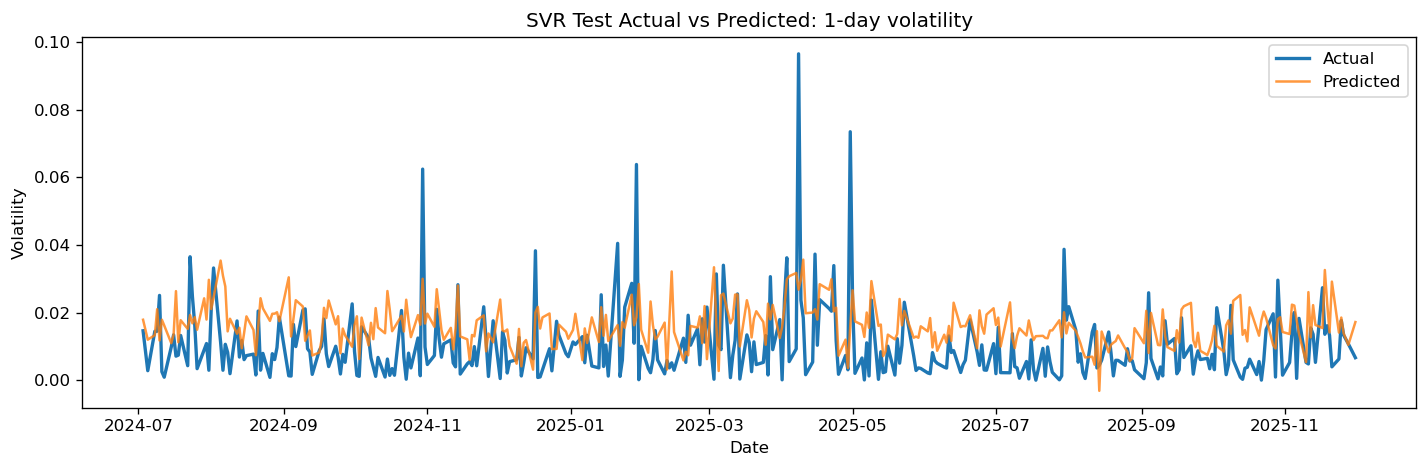

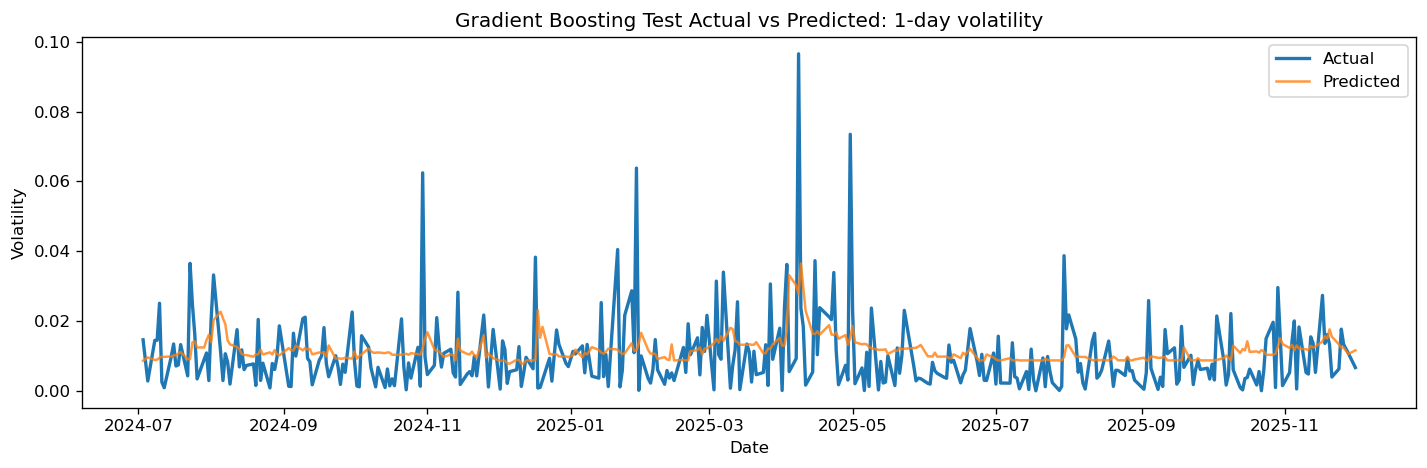

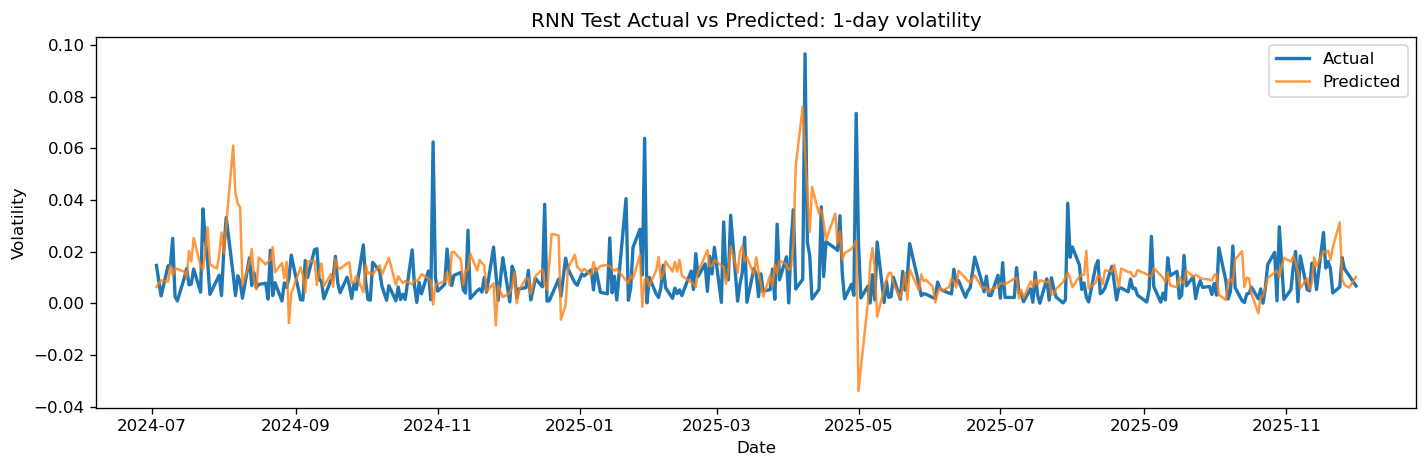

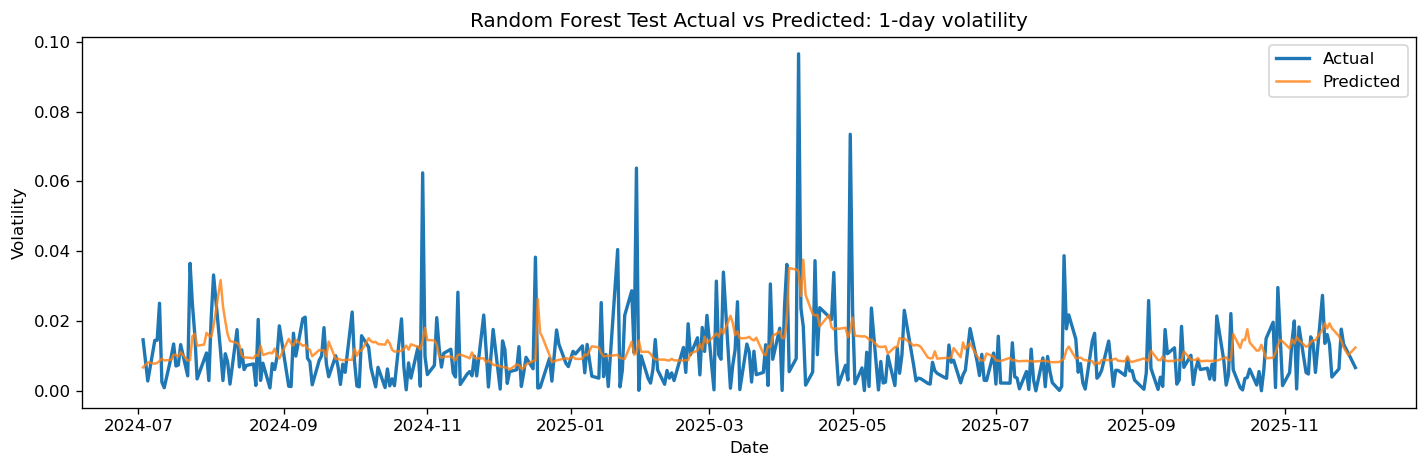

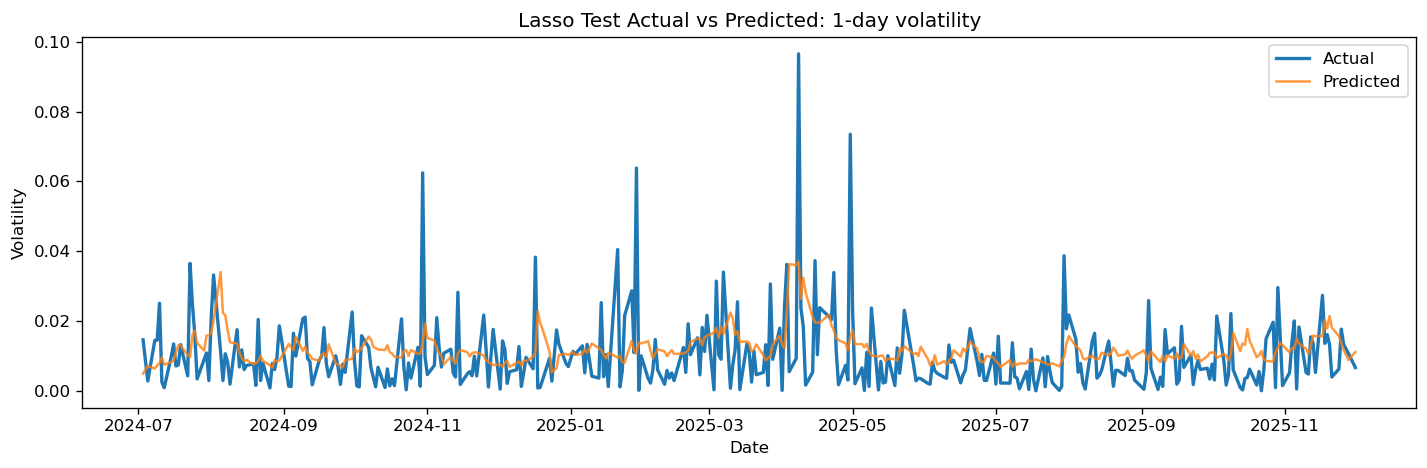

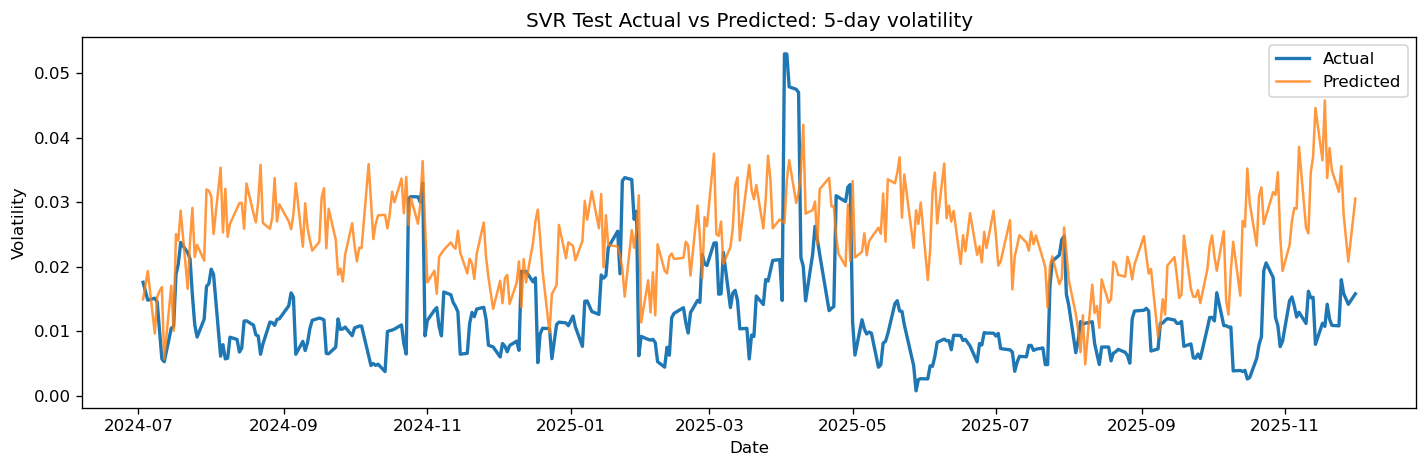

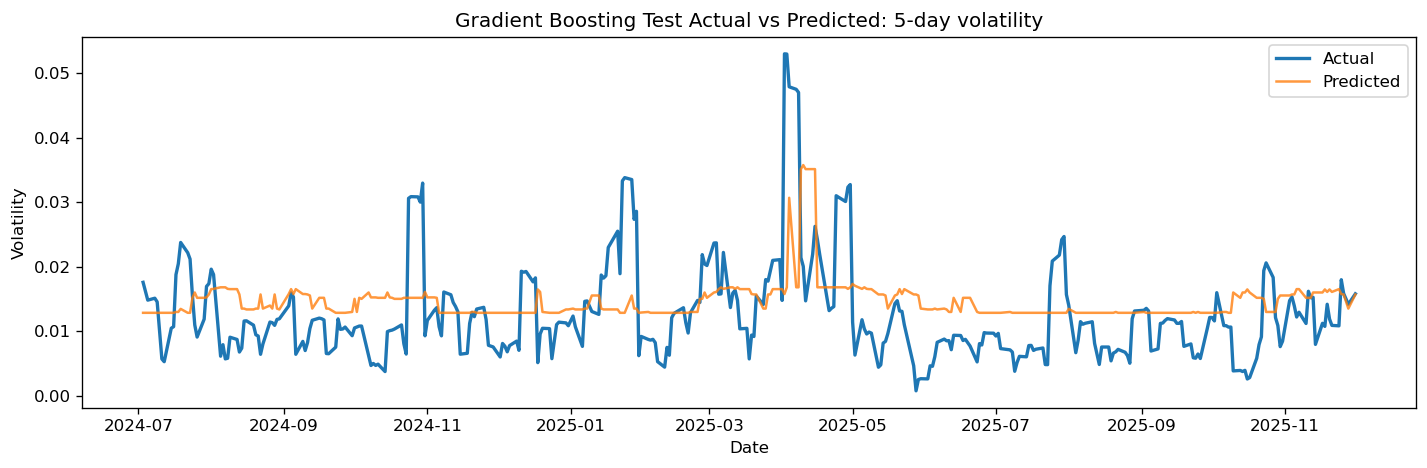

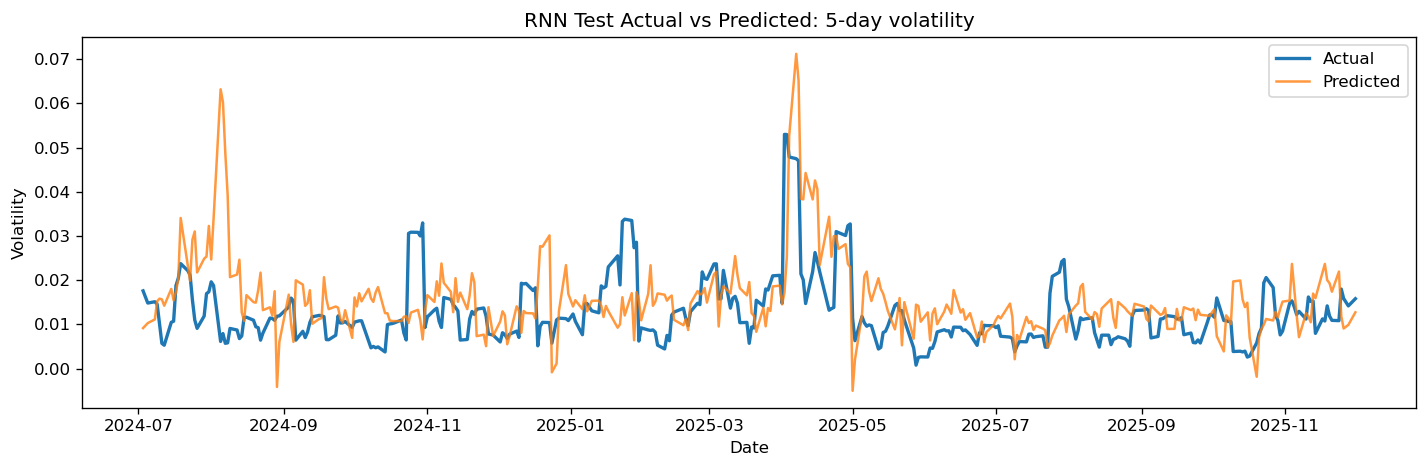

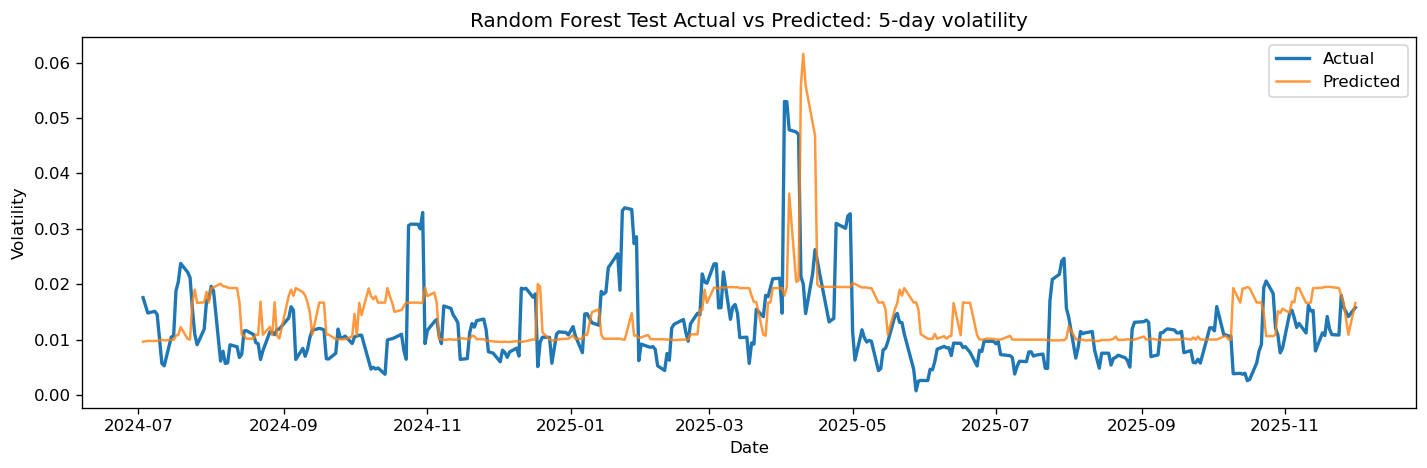

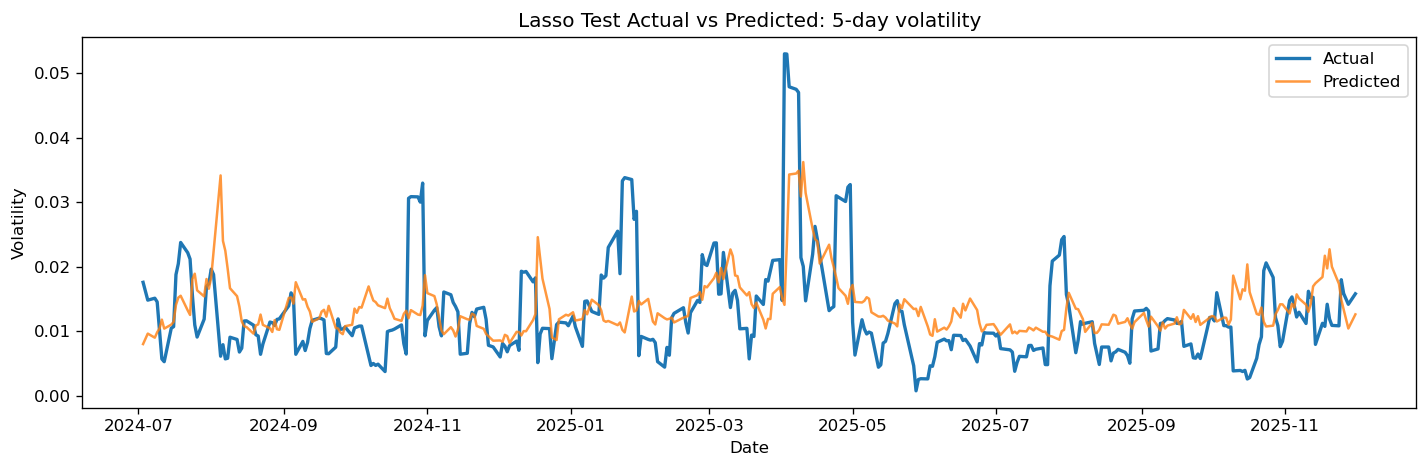

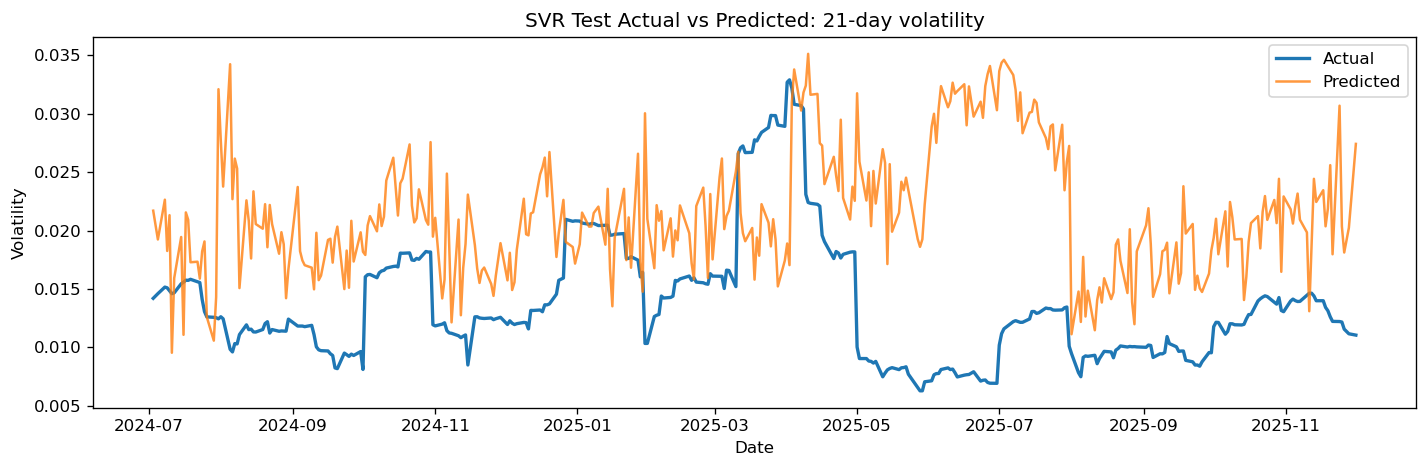

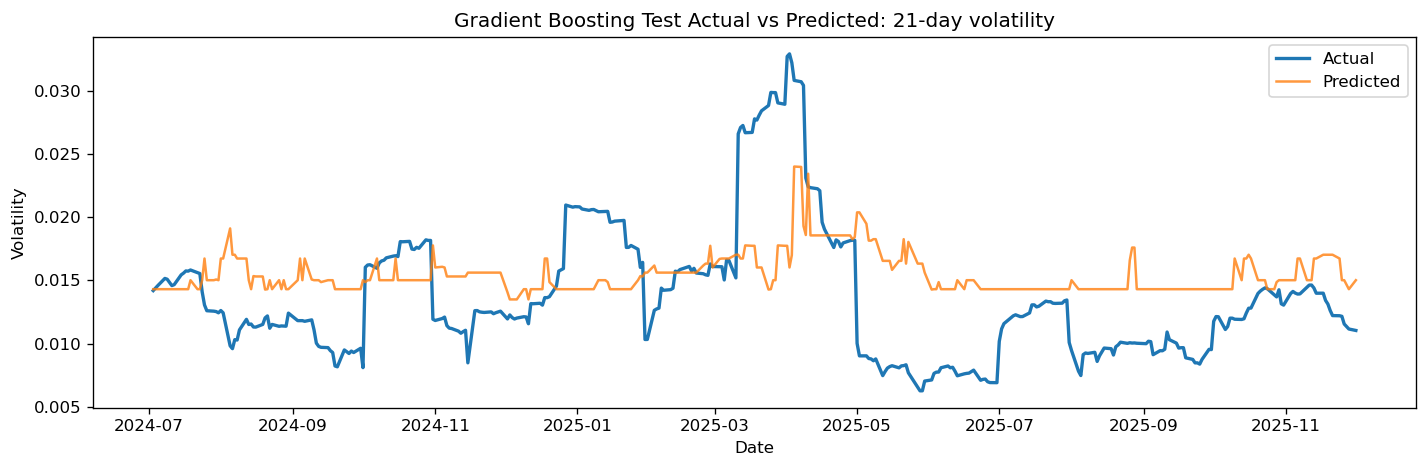

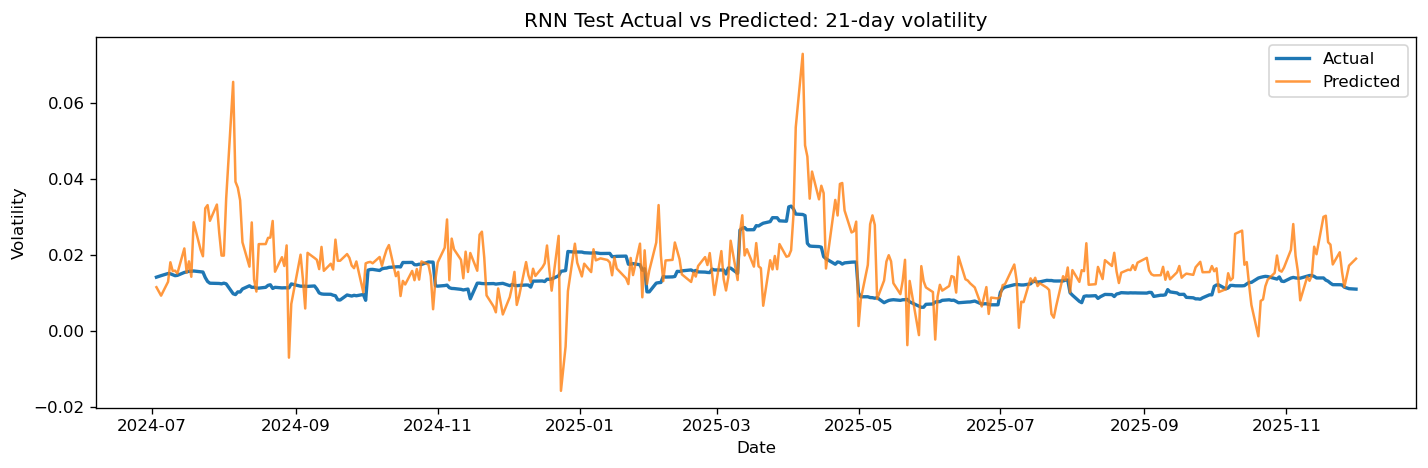

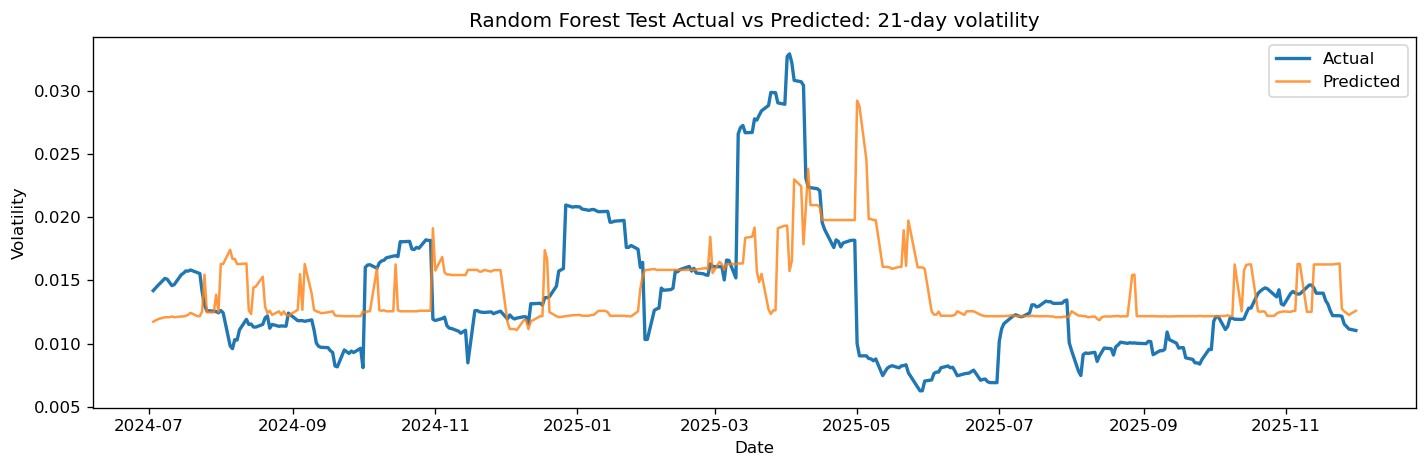

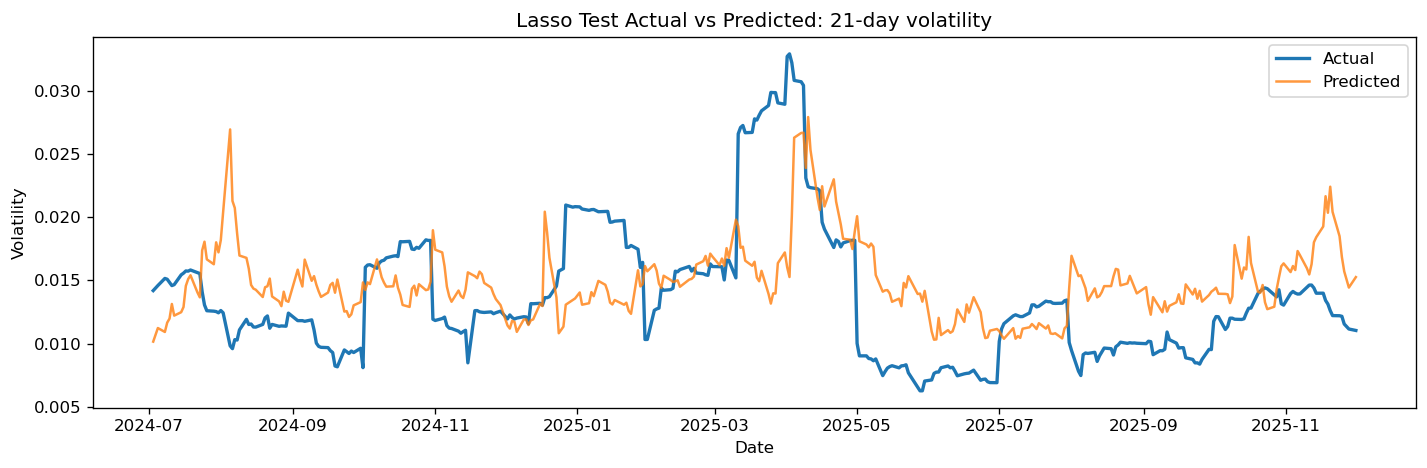

In [47]:
# Test Visualization Results
# Predicted vs Actual plots

# Daily
svr_pred_1d = plot_actual_vs_predicted_single_model(
    model=best_svr_models["1-day volatility"],
    y_true=y_test_1d,
    X_scaled=X_test_scaled,
    model_name="SVR",
    target_name="1-day volatility",
    dataset_name="Test"
)

gb_pred_1d = plot_actual_vs_predicted_single_model(
    model=best_gb_models["1-day volatility"],
    y_true=y_test_1d,
    X_scaled=X_test_scaled,
    model_name="Gradient Boosting",
    target_name="1-day volatility",
    dataset_name="Test"
)

rnn_ws_1d = get_rnn_window_size(
    best_rnn_validation_table,
    "1-day volatility"
)
rnn_pred_1d = plot_rnn_actual_vs_predicted_single_model(
    model=best_rnn_models["1-day volatility"],
    y_train=y_train_1d,
    y_valid=y_valid_1d,
    y_test=y_test_1d,
    X_train_scaled=X_train_scaled,
    X_valid_scaled=X_valid_scaled,
    X_test_scaled=X_test_scaled,
    window_size=rnn_ws_1d,
    model_name="RNN",
    target_name="1-day volatility",
    dataset_name="Test"
)

rf_pred_1d = plot_actual_vs_predicted_single_model(
    model=best_rf_models["1-day volatility"],
    y_true=y_test_1d,
    X_scaled=X_test_scaled,
    model_name="Random Forest",
    target_name="1-day volatility",
    dataset_name="Test"
)

lasso_pred_1d = plot_actual_vs_predicted_single_model(
    model=best_lasso_models["1-day volatility"],
    y_true=y_test_1d,
    X_scaled=X_test_scaled,
    model_name="Lasso",
    target_name="1-day volatility",
    dataset_name="Test"
)


# Weekly
svr_pred_5d = plot_actual_vs_predicted_single_model(
    model=best_svr_models["5-day volatility"],
    y_true=y_test_5d,
    X_scaled=X_test_scaled,
    model_name="SVR",
    target_name="5-day volatility",
    dataset_name="Test"
)

gb_pred_5d = plot_actual_vs_predicted_single_model(
    model=best_gb_models["5-day volatility"],
    y_true=y_test_5d,
    X_scaled=X_test_scaled,
    model_name="Gradient Boosting",
    target_name="5-day volatility",
    dataset_name="Test"
)

rnn_ws_5d = get_rnn_window_size(
    best_rnn_validation_table,
    "5-day volatility"
)
rnn_pred_5d = plot_rnn_actual_vs_predicted_single_model(
    model=best_rnn_models["5-day volatility"],
    y_train=y_train_5d,
    y_valid=y_valid_5d,
    y_test=y_test_5d,
    X_train_scaled=X_train_scaled,
    X_valid_scaled=X_valid_scaled,
    X_test_scaled=X_test_scaled,
    window_size=rnn_ws_5d,
    model_name="RNN",
    target_name="5-day volatility",
    dataset_name="Test"
)

rf_pred_5d = plot_actual_vs_predicted_single_model(
    model=best_rf_models["5-day volatility"],
    y_true=y_test_5d,
    X_scaled=X_test_scaled,
    model_name="Random Forest",
    target_name="5-day volatility",
    dataset_name="Test"
)

lasso_pred_5d = plot_actual_vs_predicted_single_model(
    model=best_lasso_models["5-day volatility"],
    y_true=y_test_5d,
    X_scaled=X_test_scaled,
    model_name="Lasso",
    target_name="5-day volatility",
    dataset_name="Test"
)


# Monthly
svr_pred_21d = plot_actual_vs_predicted_single_model(
    model=best_svr_models["21-day volatility"],
    y_true=y_test_21d,
    X_scaled=X_test_scaled,
    model_name="SVR",
    target_name="21-day volatility",
    dataset_name="Test"
)

gb_pred_21d = plot_actual_vs_predicted_single_model(
    model=best_gb_models["21-day volatility"],
    y_true=y_test_21d,
    X_scaled=X_test_scaled,
    model_name="Gradient Boosting",
    target_name="21-day volatility",
    dataset_name="Test"
)

rnn_ws_21d = get_rnn_window_size(
    best_rnn_validation_table,
    "21-day volatility"
)
rnn_pred_21d = plot_rnn_actual_vs_predicted_single_model(
    model=best_rnn_models["21-day volatility"],
    y_train=y_train_21d,
    y_valid=y_valid_21d,
    y_test=y_test_21d,
    X_train_scaled=X_train_scaled,
    X_valid_scaled=X_valid_scaled,
    X_test_scaled=X_test_scaled,
    window_size=rnn_ws_21d,
    model_name="RNN",
    target_name="21-day volatility",
    dataset_name="Test"
)

rf_pred_21d = plot_actual_vs_predicted_single_model(
    model=best_rf_models["21-day volatility"],
    y_true=y_test_21d,
    X_scaled=X_test_scaled,
    model_name="Random Forest",
    target_name="21-day volatility",
    dataset_name="Test"
)

lasso_pred_21d = plot_actual_vs_predicted_single_model(
    model=best_lasso_models["21-day volatility"],
    y_true=y_test_21d,
    X_scaled=X_test_scaled,
    model_name="Lasso",
    target_name="21-day volatility",
    dataset_name="Test"
)

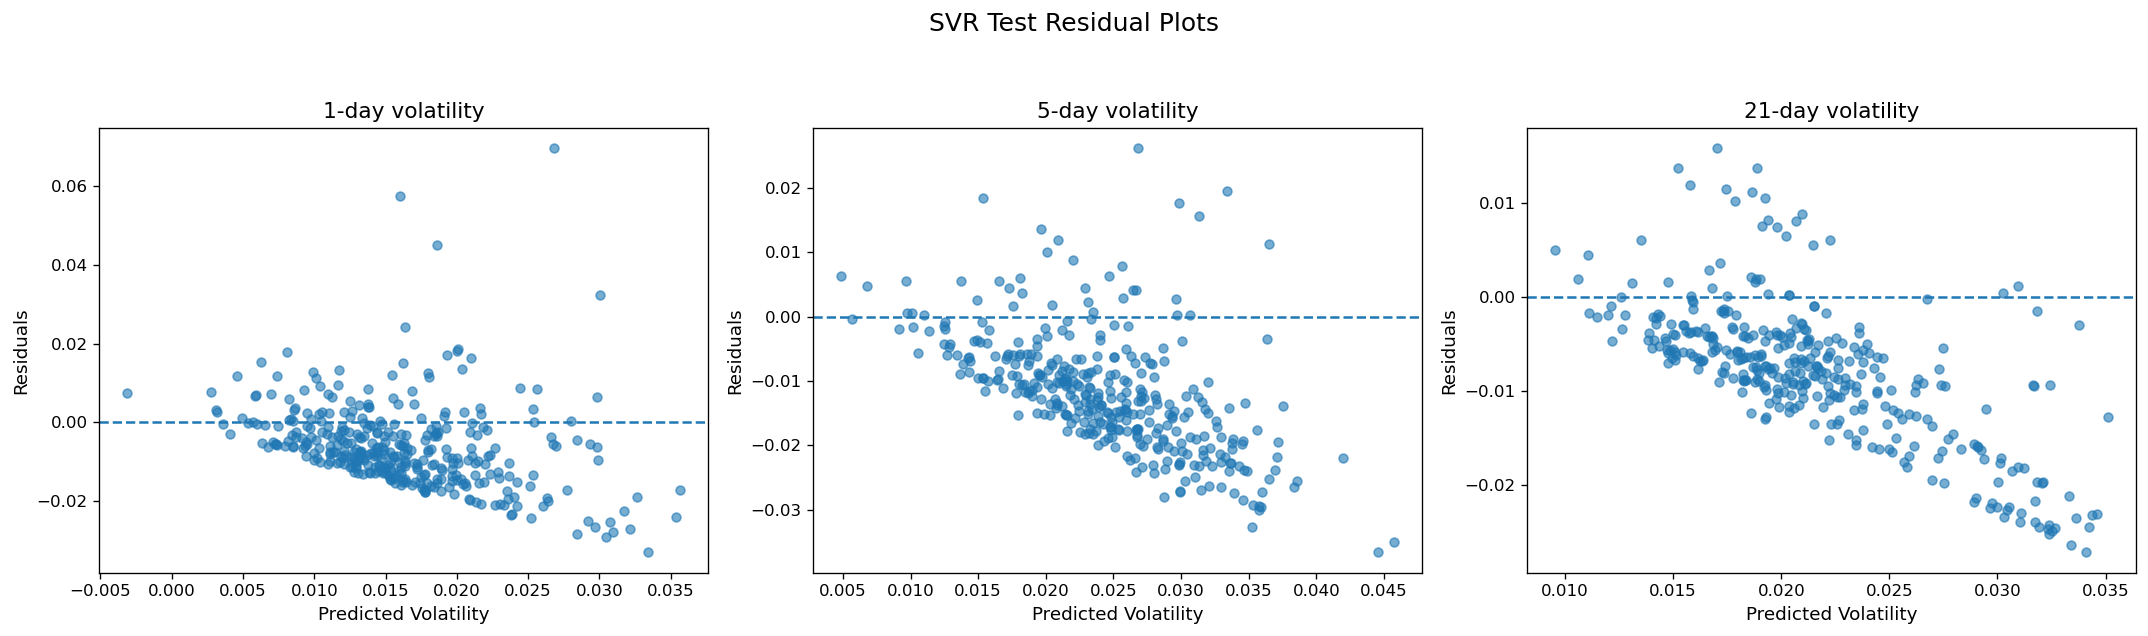

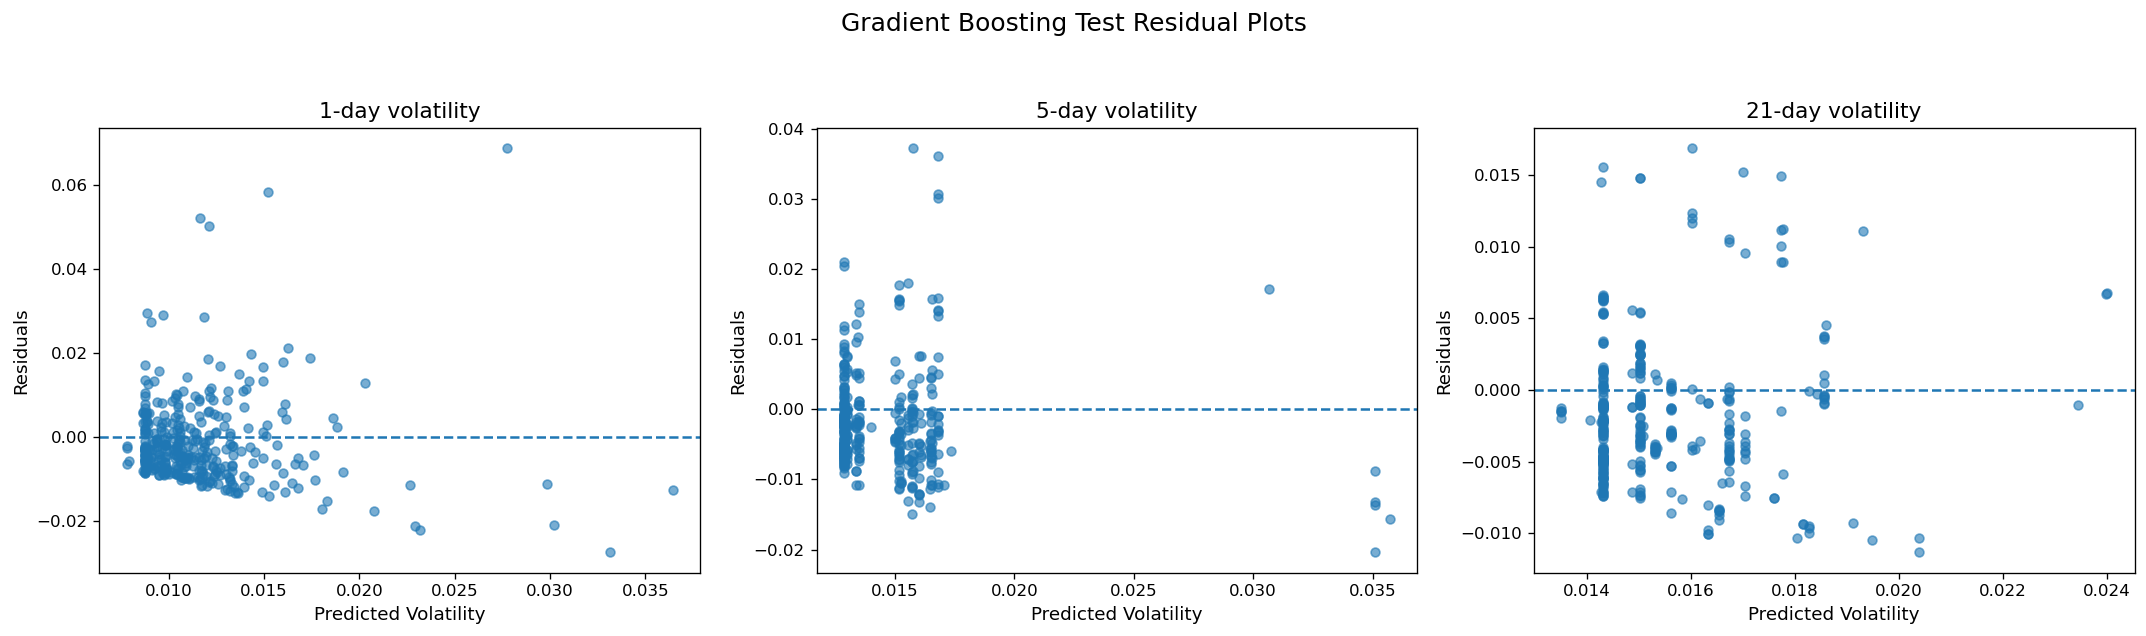

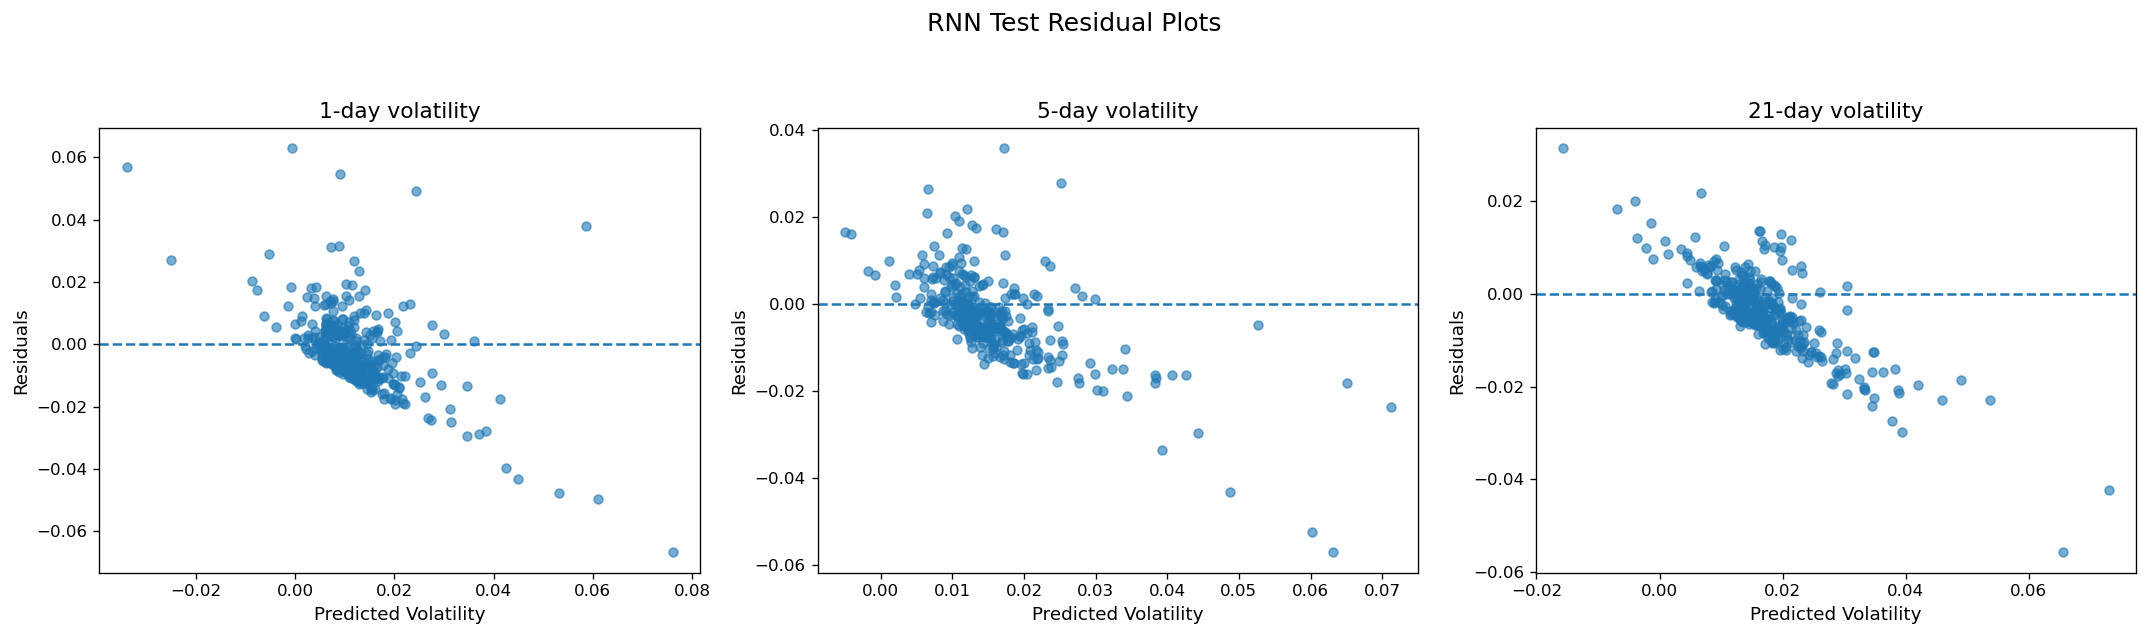

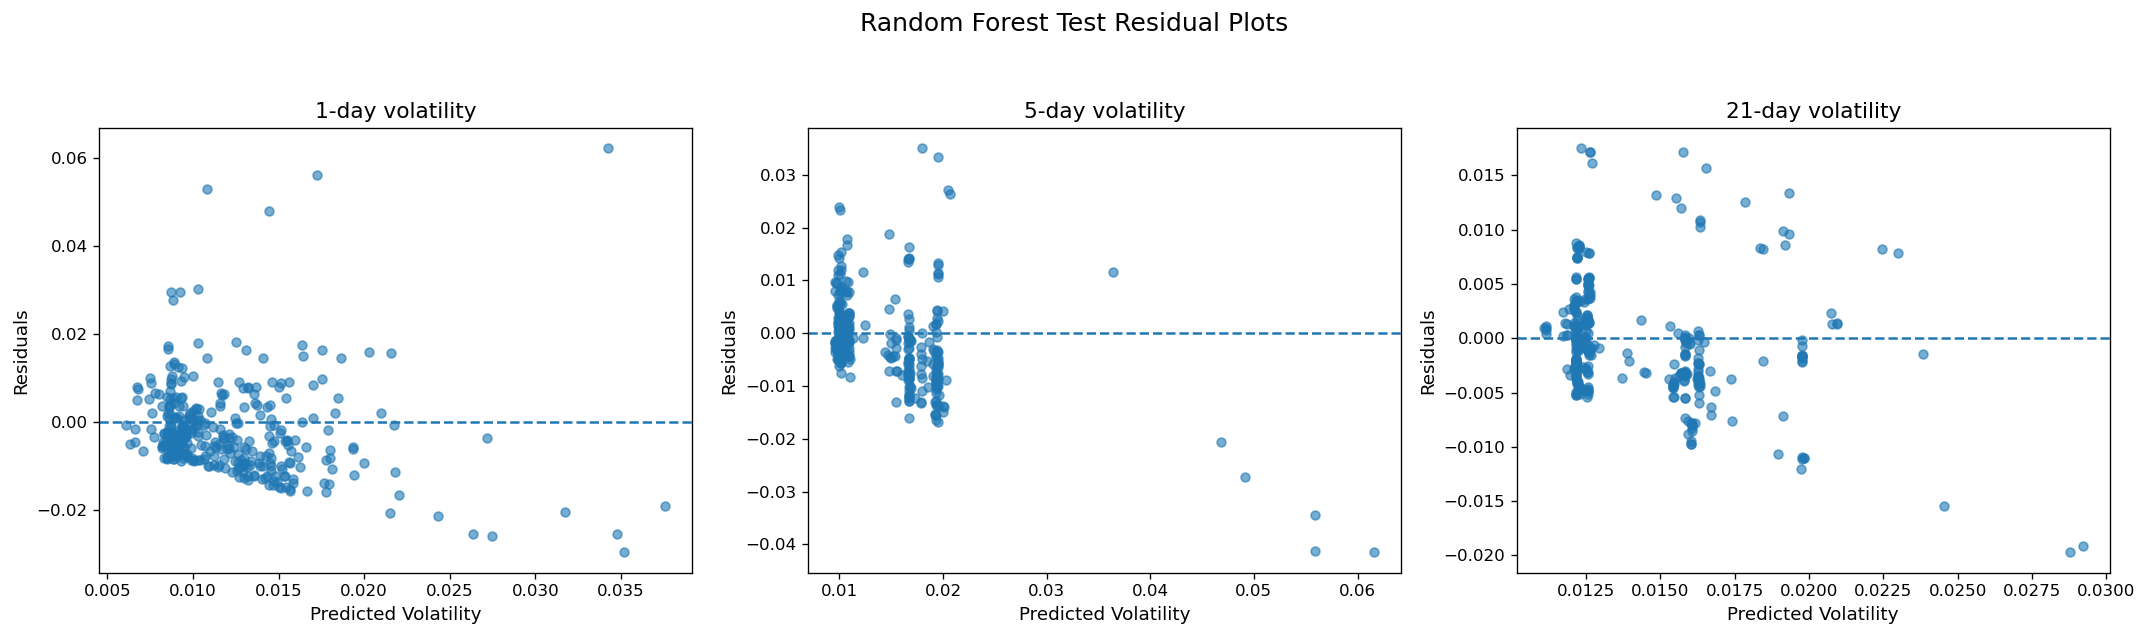

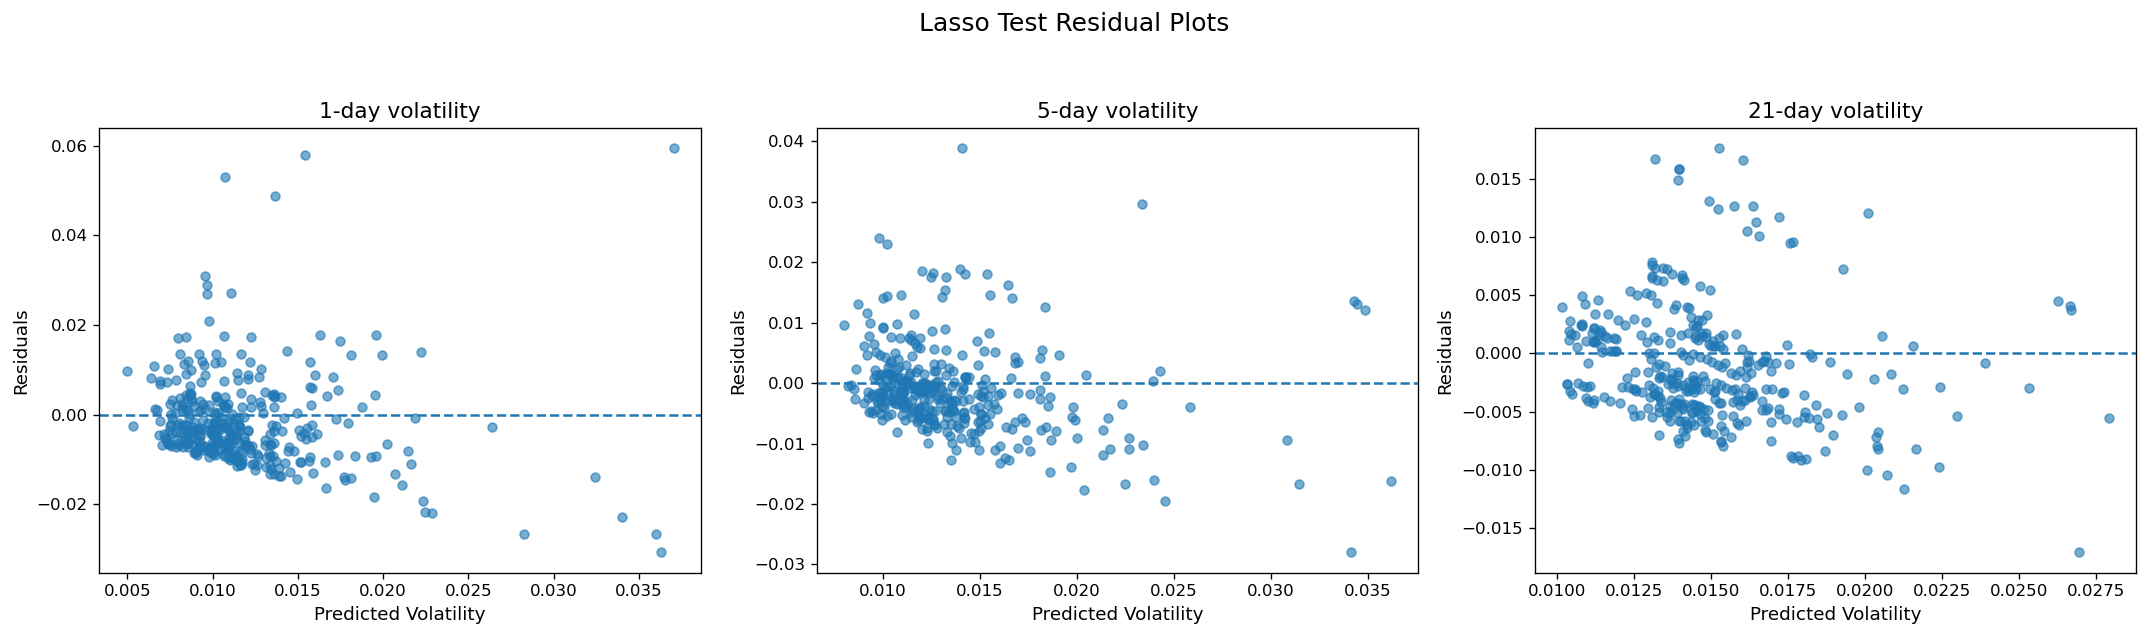

In [48]:
# Test Visualization Results
# Residual Plots

test_targets_only = {
    "1-day volatility": y_test_1d,
    "5-day volatility": y_test_5d,
    "21-day volatility": y_test_21d
}

rnn_test_targets = {
    "1-day volatility": (y_train_1d, y_valid_1d, y_test_1d),
    "5-day volatility": (y_train_5d, y_valid_5d, y_test_5d),
    "21-day volatility": (y_train_21d, y_valid_21d, y_test_21d)
}

# SVR
svr_test_residuals = plot_combined_residuals(
    models=best_svr_models,
    targets=test_targets_only,
    X_scaled=X_test_scaled,
    model_name="SVR",
    dataset_name="Test"
)

# Gradient Boosting
gb_test_residuals = plot_combined_residuals(
    models=best_gb_models,
    targets=test_targets_only,
    X_scaled=X_test_scaled,
    model_name="Gradient Boosting",
    dataset_name="Test"
)

# RNN
rnn_test_residuals = plot_combined_rnn_residuals(
    models=best_rnn_models,
    targets=rnn_test_targets,
    X_train_scaled=X_train_scaled,
    X_valid_scaled=X_valid_scaled,
    X_test_scaled=X_test_scaled,
    best_rnn_validation_table=best_rnn_validation_table,
    dataset_name="Test"
)

# Random Forest
rf_test_residuals = plot_combined_residuals(
    models=best_rf_models,
    targets=test_targets_only,
    X_scaled=X_test_scaled,
    model_name="Random Forest",
    dataset_name="Test"
)

# Lasso
lasso_test_residuals = plot_combined_residuals(
    models=best_lasso_models,
    targets=test_targets_only,
    X_scaled=X_test_scaled,
    model_name="Lasso",
    dataset_name="Test"
)

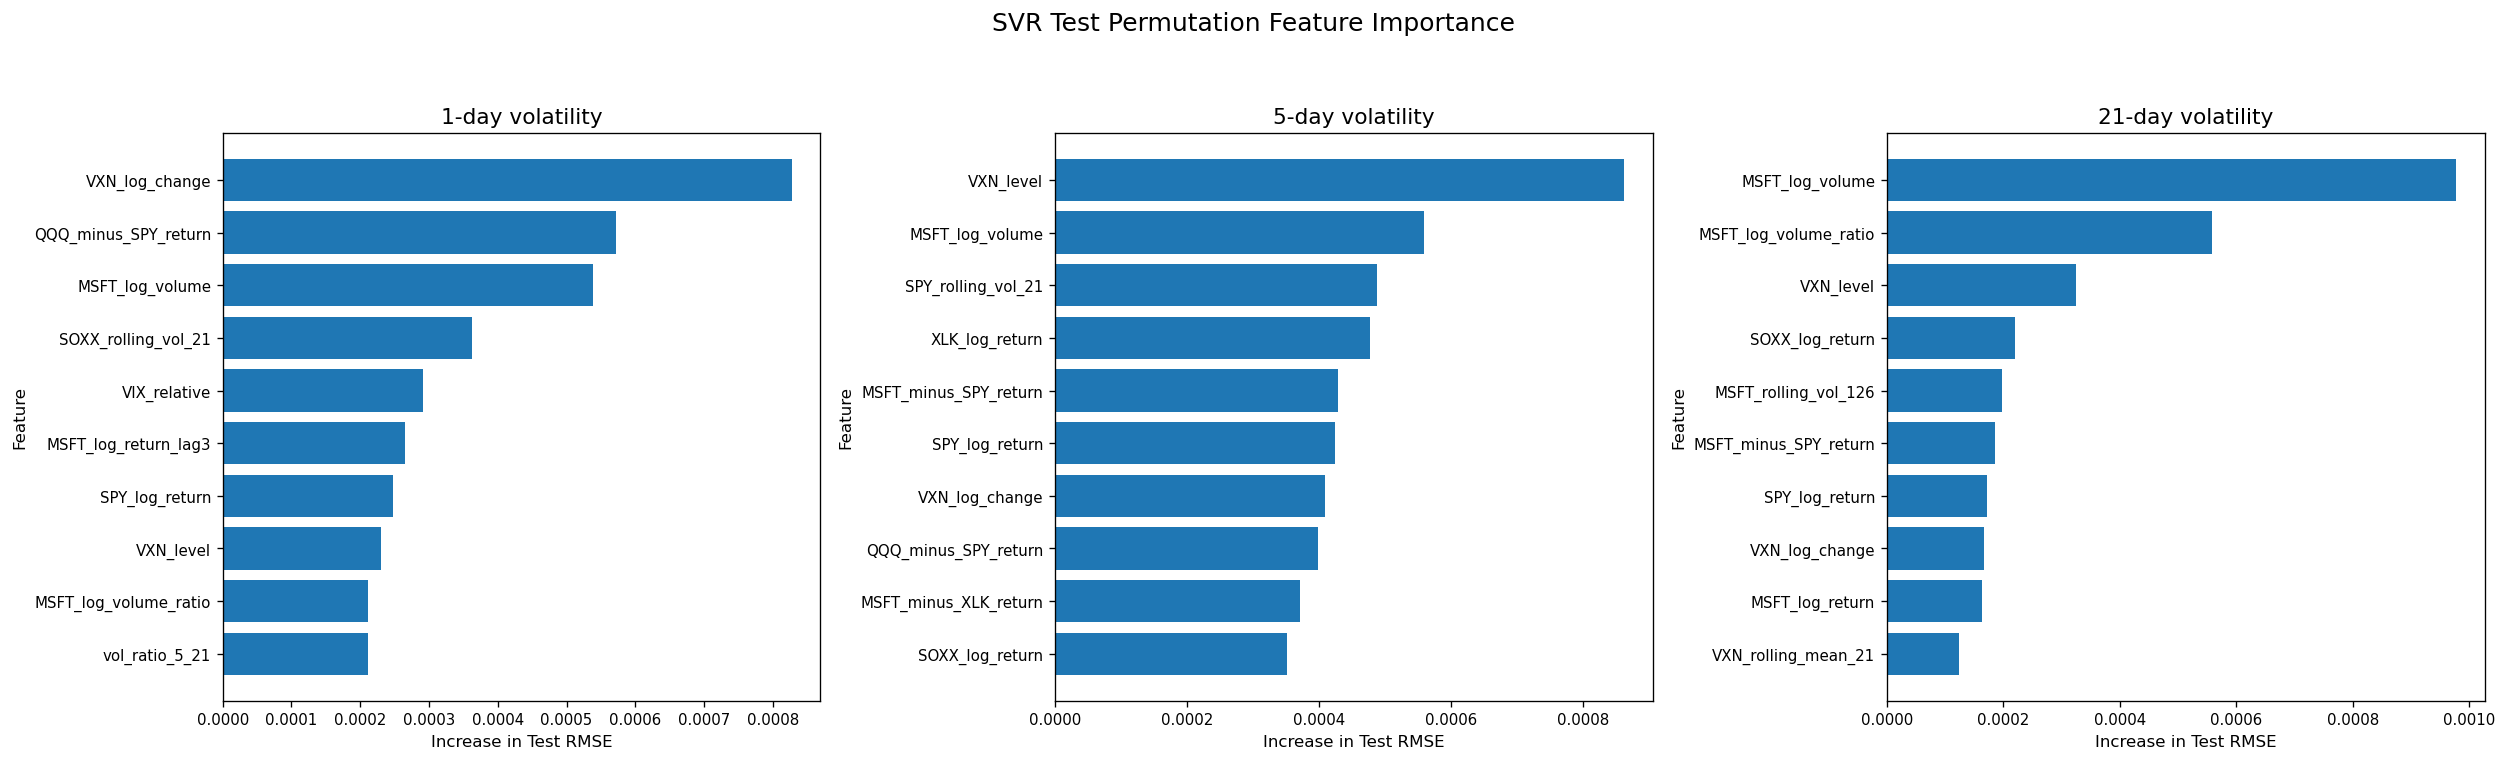

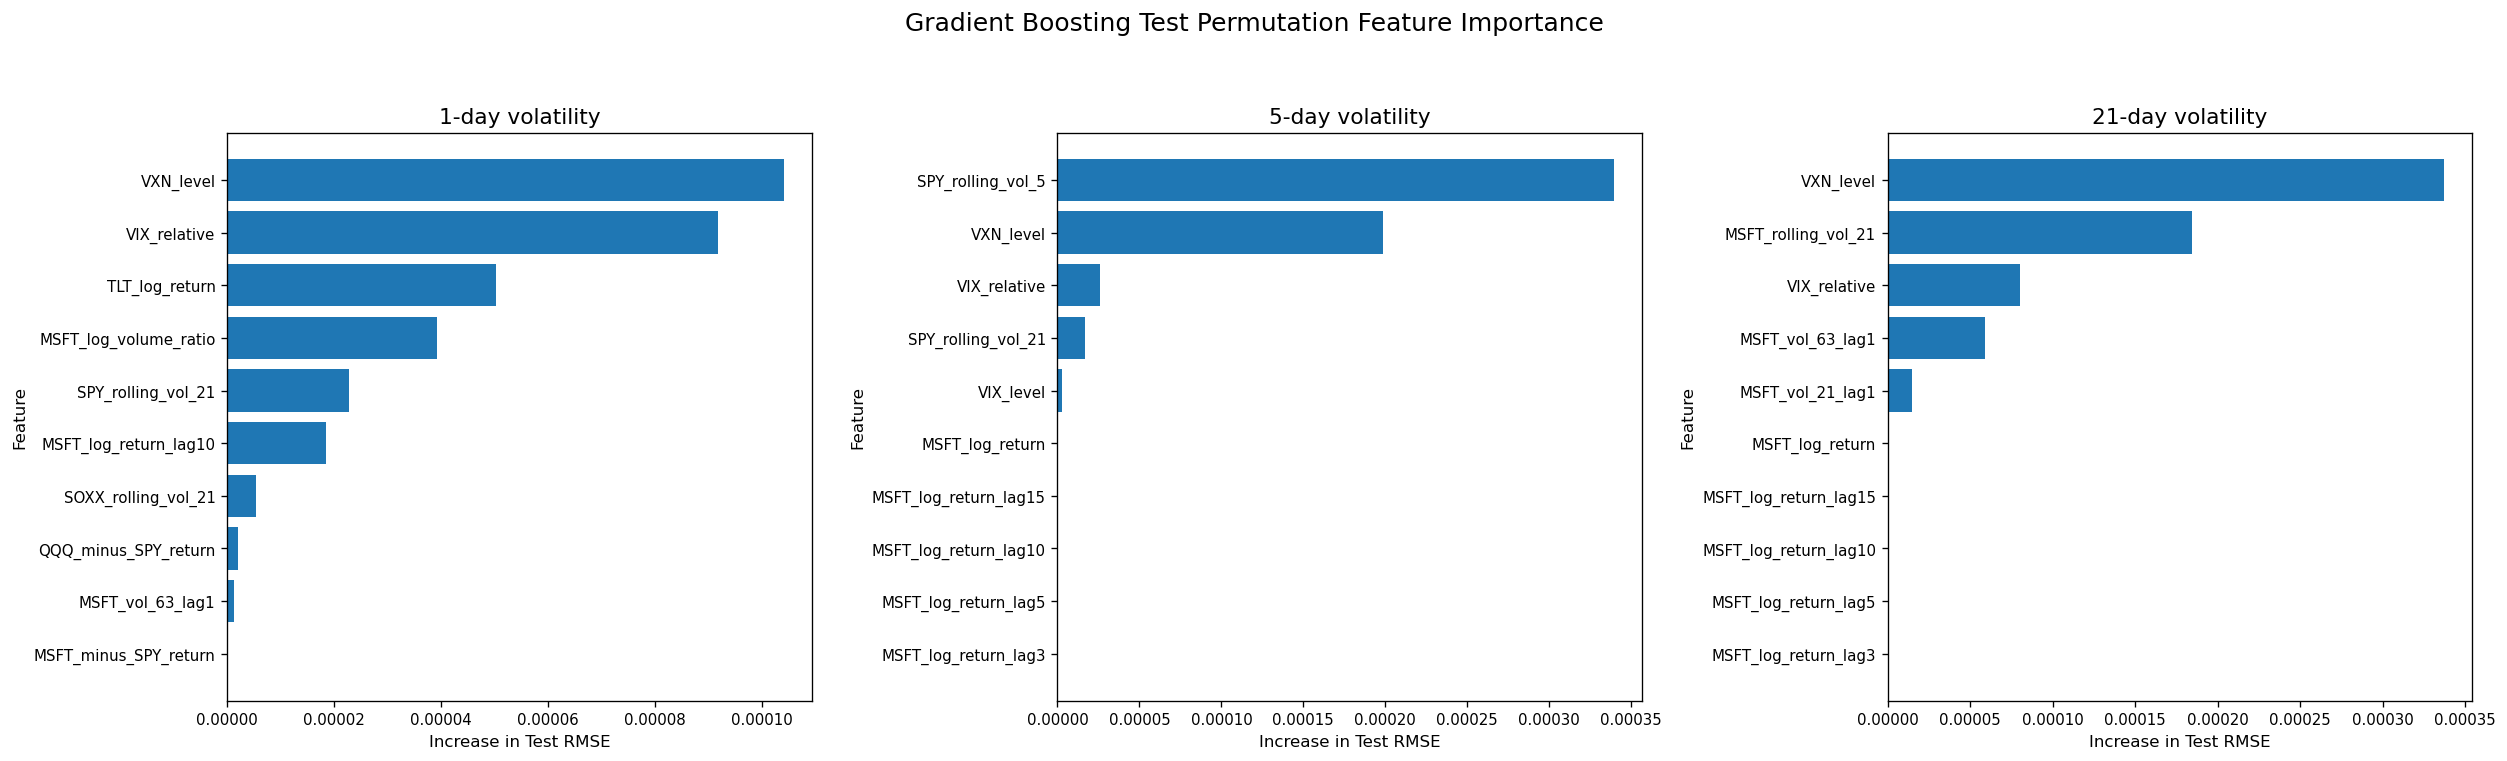

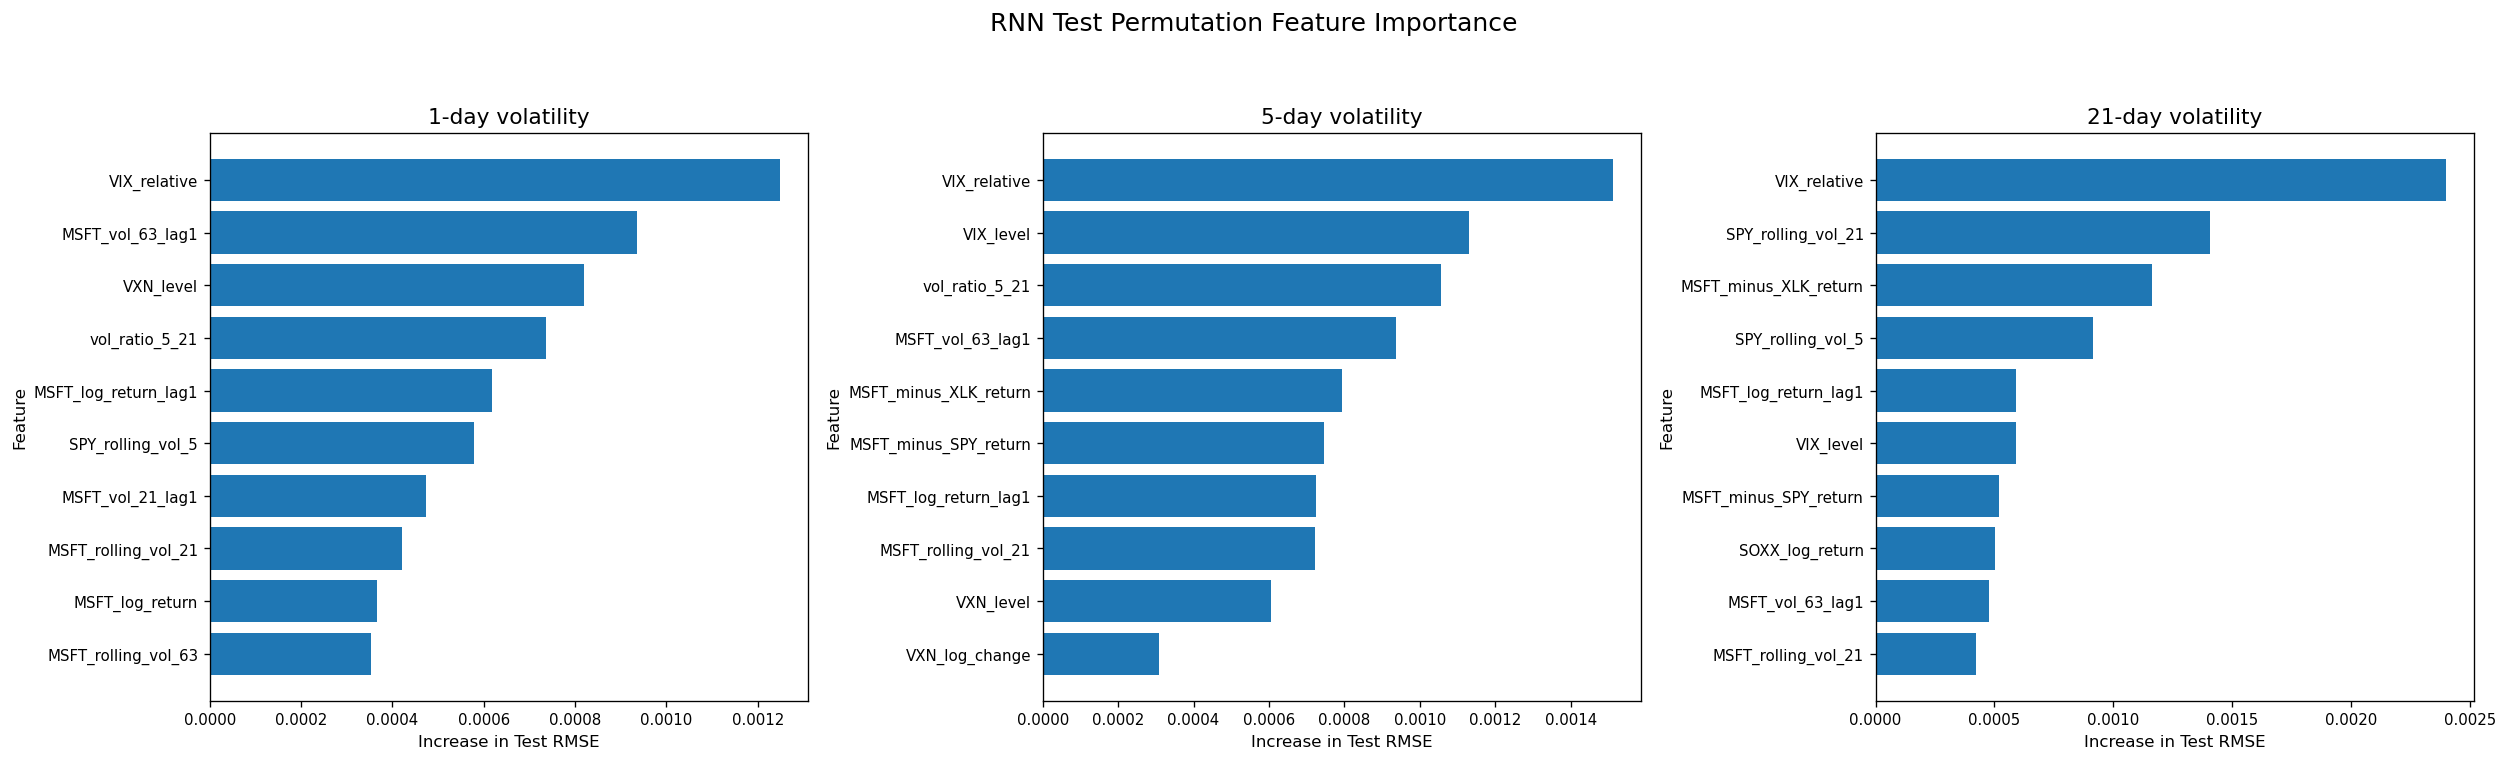

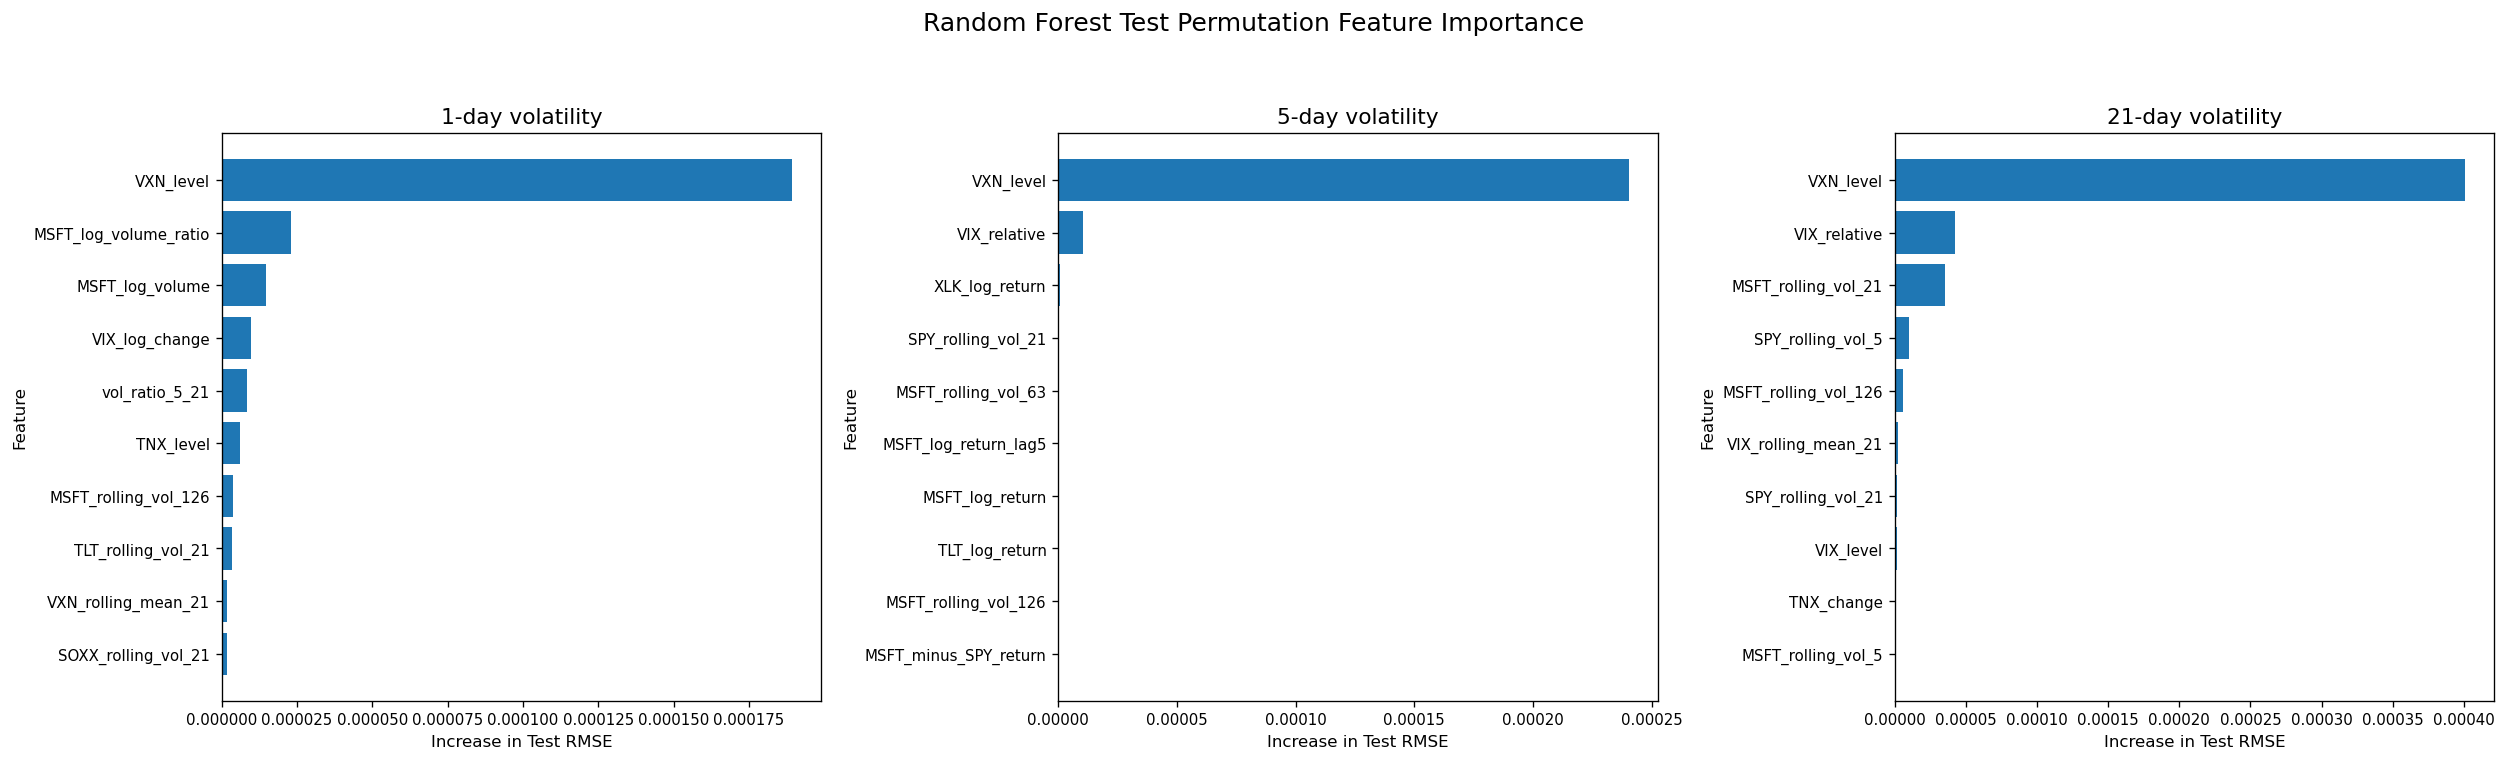

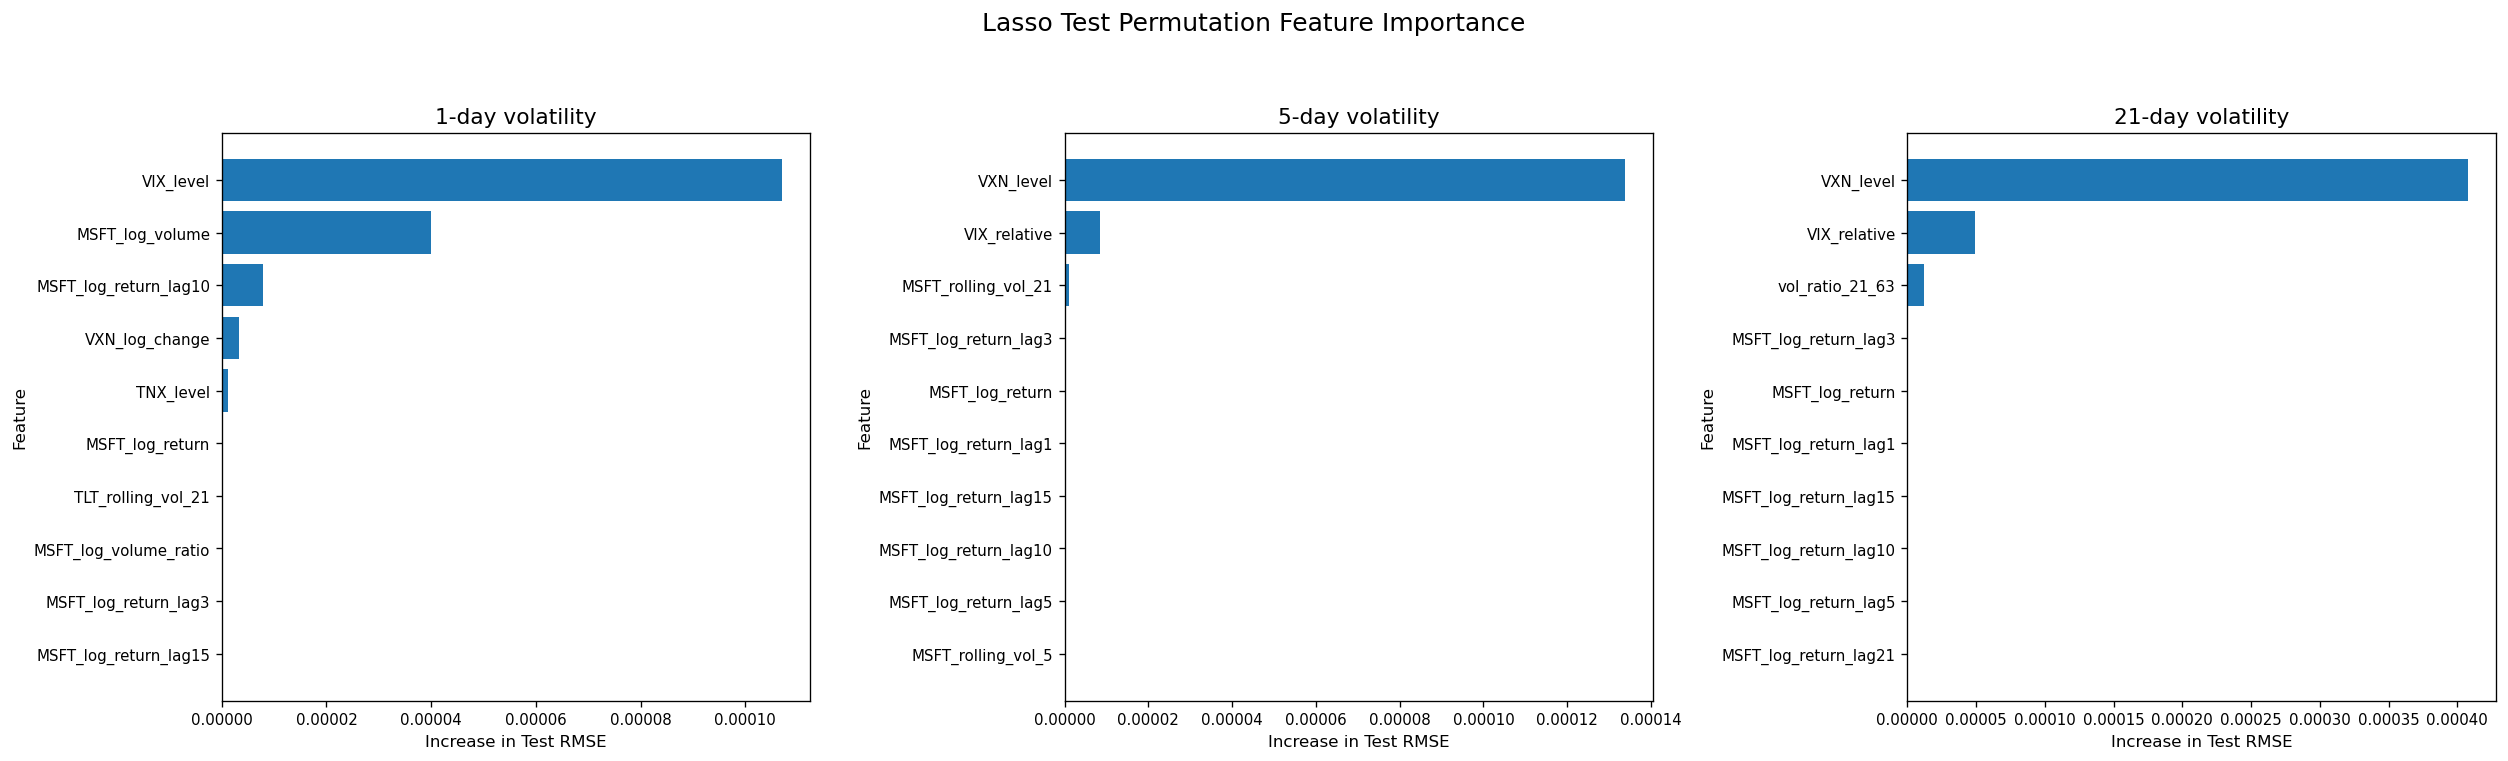

In [49]:
# Test Visualization Results
# Permutation Feature Importance Plots

# SVR
svr_test_feature_importance = plot_combined_permutation_importance(
    models=best_svr_models,
    targets=test_targets_only,
    X_scaled=X_test_scaled,
    feature_cols=feature_cols,
    model_name="SVR",
    top_n=10,
    dataset_name="Test"
)

# Gradient Boosting
gb_test_feature_importance = plot_combined_permutation_importance(
    models=best_gb_models,
    targets=test_targets_only,
    X_scaled=X_test_scaled,
    feature_cols=feature_cols,
    model_name="Gradient Boosting",
    top_n=10,
    dataset_name="Test"
)

# RNN
rnn_test_feature_importance = plot_combined_rnn_permutation_importance(
    models=best_rnn_models,
    targets=rnn_test_targets,
    X_train_scaled=X_train_scaled,
    X_valid_scaled=X_valid_scaled,
    X_test_scaled=X_test_scaled,
    best_rnn_validation_table=best_rnn_validation_table,
    feature_cols=feature_cols,
    top_n=10,
    n_repeats=10,
    dataset_name="Test"
)

# Random Forest
rf_test_feature_importance = plot_combined_permutation_importance(
    models=best_rf_models,
    targets=test_targets_only,
    X_scaled=X_test_scaled,
    feature_cols=feature_cols,
    model_name="Random Forest",
    top_n=10,
    dataset_name="Test"
)

# Lasso
lasso_test_feature_importance = plot_combined_permutation_importance(
    models=best_lasso_models,
    targets=test_targets_only,
    X_scaled=X_test_scaled,
    feature_cols=feature_cols,
    model_name="Lasso",
    top_n=10,
    dataset_name="Test"
)

# 6. Discussions and Conclusions

Make it brief; (2-3 paragraphs max)

Discuss:
- Which model performed best?
- Why do you think it performed best?
- What do the results mean in the financial context?
- Are there economic or practical implications?
- What are the limitations of the study?

Conclude:
- Summarize the main findings.
- State the major takeaway.
- Suggest possible future work.

# Appendix. Reproducibility

- State the software environment.
- State package versions if relevant.
- Explain how to reproduce the analysis.
- Ensure the notebook has been run from start to finish.


In [ ]:
# example: package versions
# import sys
# print(sys.version)
# print(pd.__version__)
# print(np.__version__)

# References

- Include all papers, datasets, websites, and software packages cited in the notebook.
- Use a consistent citation style.
